# **Group 4 Malaysia House Rental Price**

### **Group members**
- Harshini I.Thiagerajan - 36063592
- Leng Jaek-Hxiang - 35897317
- Jingyuan Yao(Stephanie) - 35595272
- Wenqi Yang - 35279850
- Yu Hanjie - 35569557

### **Project Progress**
**26 March 2025**
1. Project topic selection by all members present

**9 April 2025**
1. Research question discussion by all members present

**23 April 2025**
1. Subquestion determination by all present members
2. Discussion and initial analysis based on chosen subquestion

**7 May 2025**
1. Group meeting to standardised naming convention
2. Beginning to compile members notebooks into one notebook

**10 May 2025**
1. Initial completed draft submission

**18 May 2025**
1. Second draft submission

**22 May 2025**
1. Stephanie fixed grammatical issue, added observations for all figures and changed her question to be clearer
2. Jason Yu tidied his work in both code and documentation
3. Wenqi Yang tidied his work in both code and documentation
4. A detailed discussion was written was the final part

**2 June 2025**
Submission of final report

### **Project Background Information**
A variety of  factors influence the real estate rental market, which is important to metropolitan economies and has a direct effect on home affordability. Policymakers, real estate investors, and potential renters all need to understand the factors that influence rental costs. In this research, a dataset of residential property listings in the Klang Valley region which is Malaysia's major metropolitan centre, that includes Kuala Lumpur and its neighbouring regions like Selangor will be analysed. In order to provide a data-driven understanding of market trends and value drivers, the main goal is to investigate how different property characteristics affect monthly rental pricing.

# **Research Question : What are the factors influencing Monthly Rent Prices in KL/Selangor**

## **PART 1: IMPORTING DATA AND INITIAL OVERVIEW OF DATASET**

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# read the data
df = pd.read_csv("C:\\Users\\User\\OneDrive - Monash University\\Documents\\Y1S1 - ADS1001\\Project\\malaysia_house_rental_price_data.csv", index_col=False, sep=",")

In [3]:
df.shape

(19990, 13)

In [4]:
df.head()

,prop_name,completion_year,monthly_rent,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,city,area
0,The Hipster @ Taman Desa,2022.0,4200.0,Condominium,5.0,2.0,6.0,1842.0,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swi...","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur,Taman Desa
1,Segar Courts,NaN,2300.0,Condominium,3.0,1.0,2.0,1170.0,Partially Furnished,"Playground, Parking, Barbeque area, Security, ...","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur,Cheras
2,Pangsapuri Teratak Muhibbah 2,NaN,1000.0,Apartment,3.0,NaN,2.0,650.0,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur,Taman Desa
3,Sentul Point Suite Apartment,2020.0,1700.0,Apartment,2.0,1.0,2.0,743.0,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Cou...","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur,Sentul
4,Arte Mont Kiara,NaN,1299.0,Service Residence,1.0,1.0,1.0,494.0,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...",Air-Cond,Kuala Lumpur,Mont Kiara


In [5]:
df.tail()

,prop_name,completion_year,monthly_rent,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,city,area
19985,Pangsapuri Gapura Bayu,NaN,1200.0,Apartment,3.0,NaN,2.0,1000.0,Partially Furnished,"Security, Parking, Lift, Minimart, Multipurpos...",Near KTM/LRT,Selangor,Kajang
19986,BSP 21,2018.0,1300.0,Service Residence,4.0,2.0,3.0,1427.0,Partially Furnished,"Jogging Track, Barbeque area, Playground, Swim...","Air-Cond, Cooking Allowed",Selangor,Bandar Saujana Putra
19987,Ameera Residence,NaN,1350.0,Condominium,3.0,2.0,2.0,1270.0,Partially Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...","Air-Cond, Cooking Allowed, Washing Machine",Selangor,Kajang
19988,The Arc @ Cyberjaya,NaN,1200.0,Service Residence,3.0,1.0,2.0,1100.0,Fully Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...","Cooking Allowed, Washing Machine",Selangor,Cyberjaya
19989,Tamarind Suites @ Cyberjaya,2016.0,1000.0,Studio,1.0,1.0,1.0,580.0,Partially Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...","Air-Cond, Cooking Allowed, Washing Machine",Selangor,Cyberjaya


#### Preliminary/Initial Observations

The Malaysia House Rental Price Dataset have ***19990 observations*** in ***13 variables*** 

Looking at the first five and last five rows of the data tells us that the dataset has a mix of continuous and categorical data in it. 

In [6]:
df.columns

Index(['prop_name', 'completion_year', 'monthly_rent', 'property_type',
       'rooms', 'parking', 'bathroom', 'size', 'furnished', 'facilities',
       'additional_facilities', 'city', 'area'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19990 entries, 0 to 19989
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prop_name              18927 non-null  object 
 1   completion_year        10716 non-null  float64
 2   monthly_rent           19873 non-null  float64
 3   property_type          19873 non-null  object 
 4   rooms                  19866 non-null  float64
 5   parking                14190 non-null  float64
 6   bathroom               19868 non-null  float64
 7   size                   19873 non-null  float64
 8   furnished              19870 non-null  object 
 9   facilities             17667 non-null  object 
 10  additional_facilities  13944 non-null  object 
 11  city                   19873 non-null  object 
 12  area                   19873 non-null  object 
dtypes: float64(6), object(7)
memory usage: 2.0+ MB


#### Initial Observation (Continued)

Based on the info( ), we can get a few information about the data, namely:

- The `<class 'pandas.core.frame.DataFrame'>` gives type of the data which is `dataframe` type 
- The `RangeIndex: 19990 entries, 0 to 19989` gives the data range. Based on it, the data ranges from 0 to 19989. Data range in also the total number of observation the data has.
- The `Data columns (total 13 columns)` gives the total number of variables in the data. Based on it, the data has 13 variables
- The `Non-Null Count` details whether the number of variablesthat is `Non null`(not empty) and `Null`(empty)
- The `dtypes` gives the type of data in the variable

*The dataset is of multivariate data types having both continuous and categorical data types in it. There are 19990 observations contained in 13 variables. And the total memory usage is 2.0+ MB*

## **PART 2: DATA ANALYSIS**

## **Subquestion 1: How do property types influence rental prices?**
### Harshini I.Thiagerajan - (36063592)

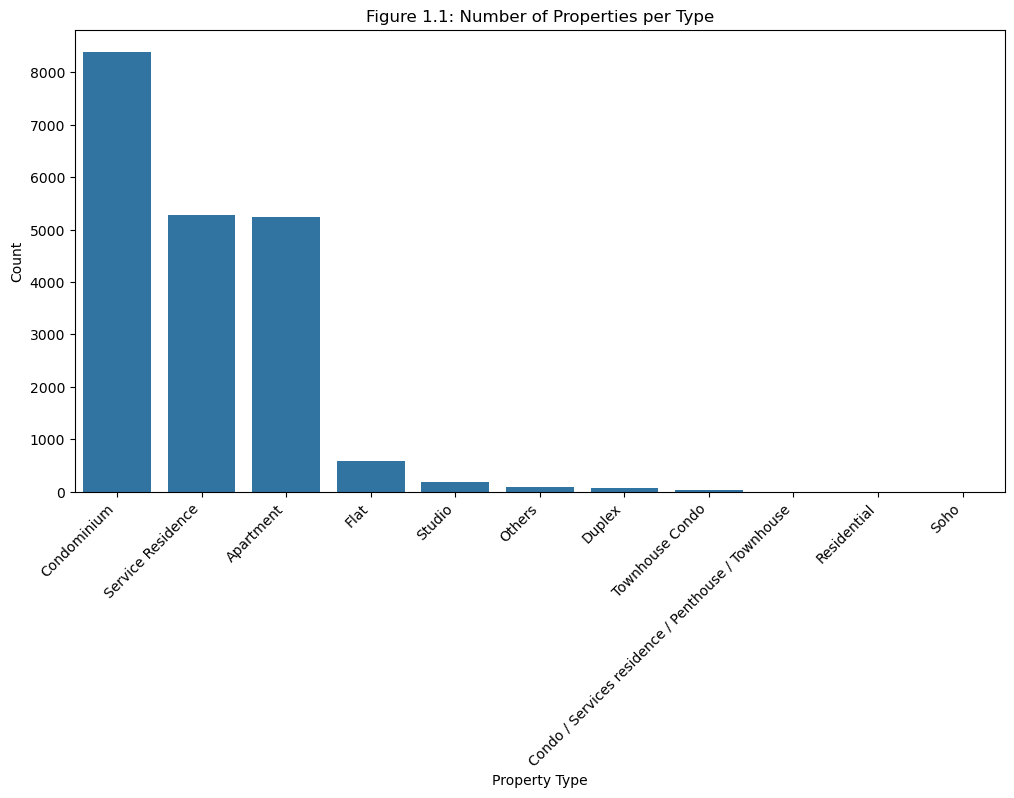

In [8]:
order = df['property_type'].value_counts().index
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='property_type', order=order).set(title='Figure 1.1: Number of Properties per Type')
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation

Figure 1.1 displays the number of property by type, ordered from the highest count to lowest. As shown, the most common property type in the dataset is **Condominium** with a count of approximately 8100 unit. The second most common property type is Service Residence with a count of approximately 5100 unit and followed closely by Apartment as the third. The least common property type **Residential** and **Soho**.

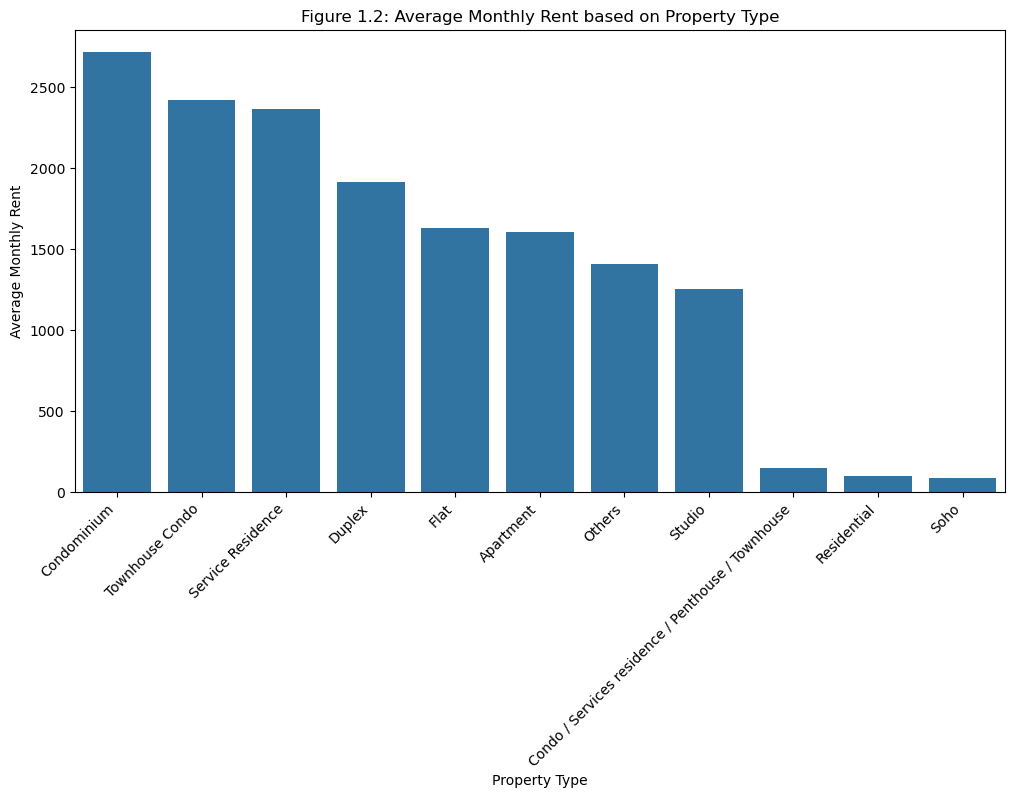

In [9]:
rent_by_property = df.groupby('property_type')['monthly_rent'].mean().reset_index()

rent_by_property_sorted = rent_by_property.sort_values(by='monthly_rent', ascending=False)
order = rent_by_property_sorted['property_type']

plt.figure(figsize=(12, 6))

sns.barplot(x='property_type', y='monthly_rent', data=rent_by_property, order = order)
plt.title("Figure 1.2: Average Monthly Rent based on Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Monthly Rent")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation

Figure 1.2 shows the average monthly rent based on property type. As observed, **Condominium** has the highest average monthly rent, at nearly RM2750. Both Townhouse Condo and Service Residence have relatively similar average monthly rents, with Townhouse Condo having a slightly higher average than Service Residence. Compared to all, **Soho** have the lowest average monthly rent, at nearly RM100.  

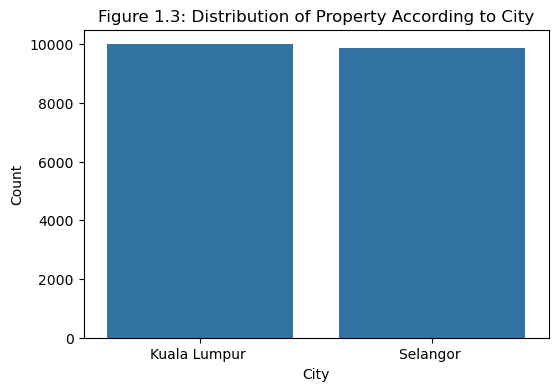

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='city', data=df)
plt.title('Figure 1.3: Distribution of Property According to City')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

#### Observation

Figure 1.3 shows the distribution of property according to city. Both Kuala Lumpur and Selangor have nearly the same number of properties, with Kuala Lumpur having slightly higher count than Selangor

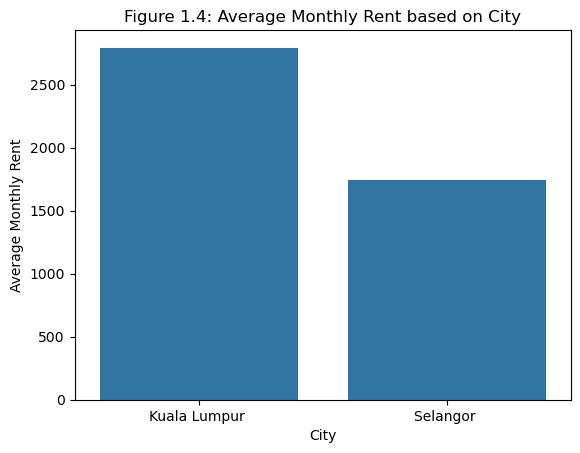

In [11]:
rent_by_city = df.groupby('city')['monthly_rent'].mean().reset_index()

#plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='monthly_rent', data=rent_by_city)
plt.xlabel("City")
plt.ylabel("Average Monthly Rent")
plt.title("Figure 1.4: Average Monthly Rent based on City")
plt.xticks(rotation=0)
plt.show()

#### Observation
Figure 1.4 shows the average monthly rent for Kuala Lumpur and Selangor. Even though, initially it was observed that both cities have approximately the same number of properties, it is clear that Kuala Lumpur have a higher average monthly rent compared to Selangor.

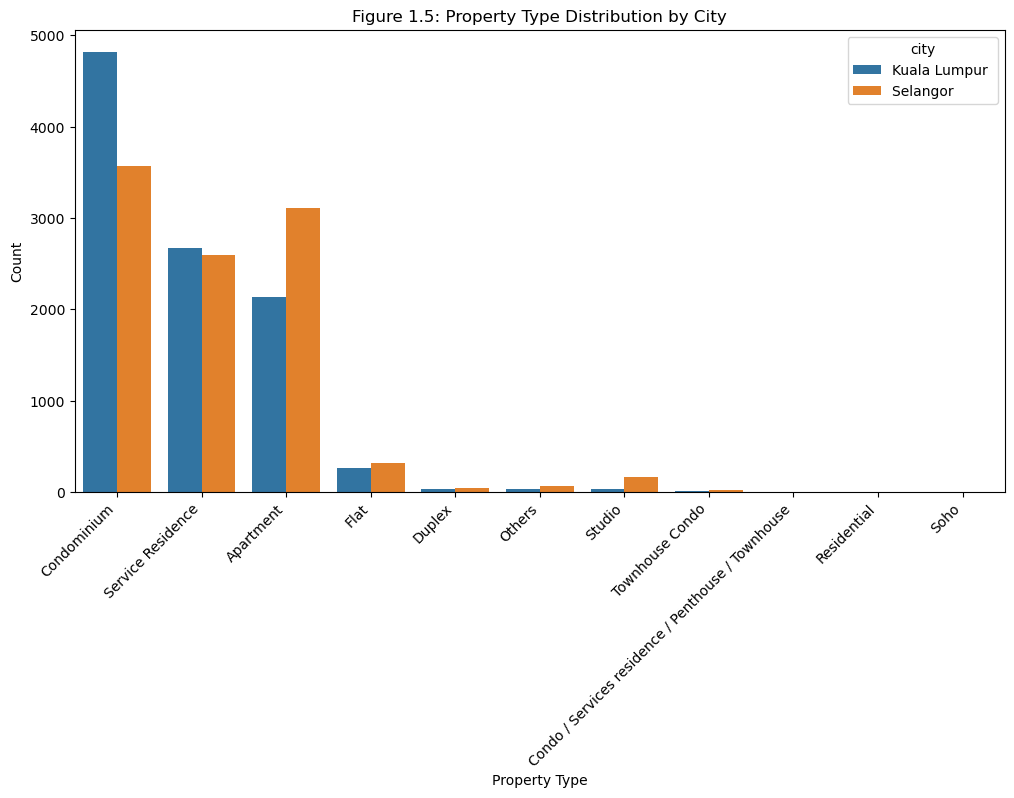

In [12]:
property_count = df.groupby(['city'])['property_type'].value_counts().reset_index(name='Count')
plt.figure(figsize=(12, 6))
sns.barplot(x='property_type', y='Count', hue='city', data=property_count)
plt.title('Figure 1.5: Property Type Distribution by City')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation

Figure 1.5 shows the number of different property type in Kuala Lumpur and Selangor. As shown above, **Condominium** has the highest count in both cities, with Kuala Lumpur having a notably higher count of approximately 4900 units than Selangor which has 3600 units. Service Residence and Apartment are also among the top three in both the cities. 

In terms of Service apartment, Kuala Lumpur also have a higher count compared to Selangor, even though the difference between these two cities is less significant compared to Condominium. On the other hand, Selangor have a higher count of Apartment, approximately 3200 unit compared to Kuala Lumpur which has approximately 2100 unit.

Property type such as flat, duplex, studio and others have relatively low count in both cities, with Selangor having slightly more of these units compared to Kuala Lumpur. Residential and Soho have extremely low count in both the cities.

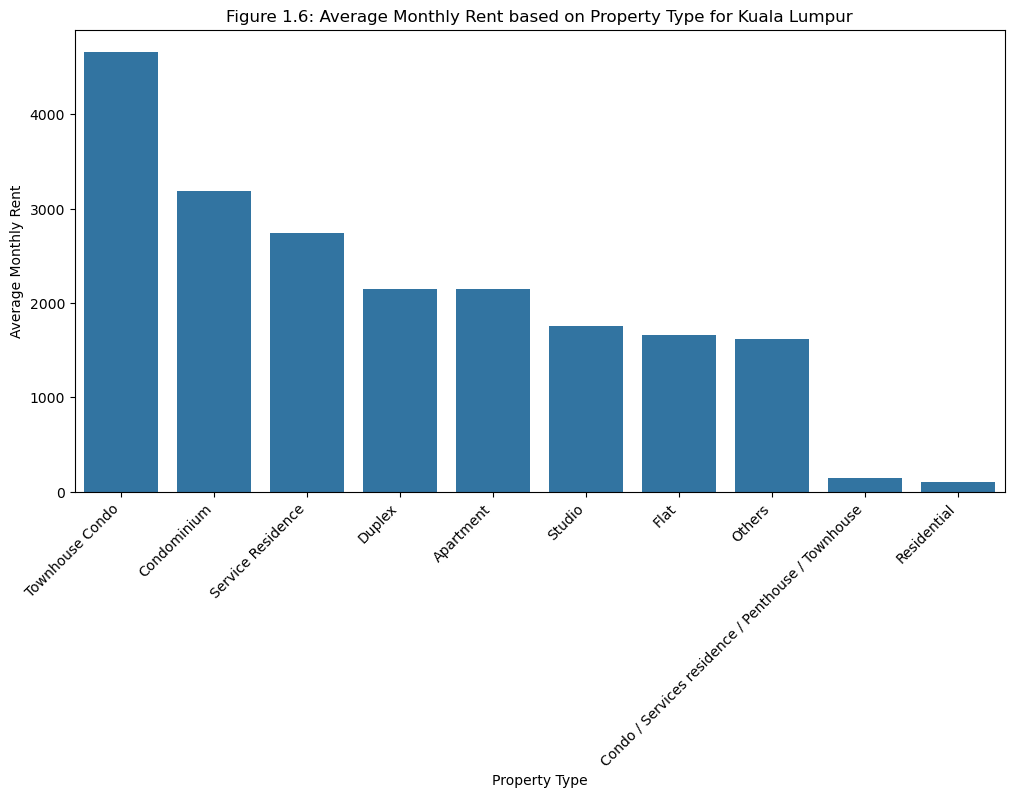

In [13]:
kuala_lumpur_df = df[df['city'] == 'Kuala Lumpur ']
rent_by_property = kuala_lumpur_df.groupby('property_type')['monthly_rent'].mean().reset_index()

rent_by_property_sorted = rent_by_property.sort_values(by='monthly_rent', ascending=False)
order = rent_by_property_sorted['property_type']

plt.figure(figsize=(12, 6))
sns.barplot(x='property_type', y='monthly_rent', data=rent_by_property, order=order)
plt.xlabel("Property Type")
plt.ylabel("Average Monthly Rent")
plt.title("Figure 1.6: Average Monthly Rent based on Property Type for Kuala Lumpur")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation

Figure 1.6 shows the average monthly rent for each of the property type in Kuala Lumpur. **Townhouse Condo** has the highest average monthly rent of approximately RM4700. Condominium has the second highest average monthly rent of approximately RM3100 in Kuala Lumpur. There is a significant difference between the average monthly of Townhouse Condo and Condominium. Also in the top three is Service Residence with an average monthly rent of approximately RM2900. 

The Duplex and Apartment have nearly the same average monthly rent of approximately RM2100. Property type such as Studio, Flat and Others have an average monthly rent that is just slightly below RM2000.

Residential in Kuala Lumpur has the lowest average monthly rent of approximately RM100 compared to all

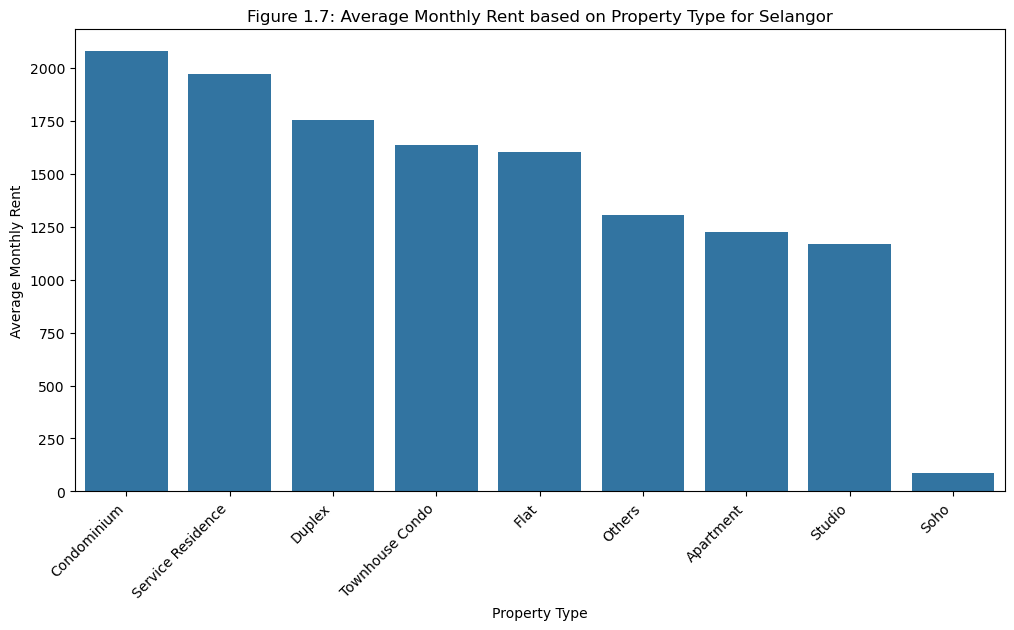

In [14]:
selangor_df = df[df['city'] == 'Selangor ']
rent_by_property = selangor_df.groupby('property_type')['monthly_rent'].mean().reset_index()

rent_by_property_sorted = rent_by_property.sort_values(by='monthly_rent', ascending=False)
order = rent_by_property_sorted['property_type']

plt.figure(figsize=(12, 6))
sns.barplot(x='property_type', y='monthly_rent', data=rent_by_property, order=order)
plt.xlabel("Property Type")
plt.ylabel("Average Monthly Rent")
plt.title("Figure 1.7: Average Monthly Rent based on Property Type for Selangor")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation
Figure 1.7 shows the average monthly rent for each of the property type in Selangor. **Condominium** has the highest average monthly rent of approximately RM2100. **Service Residence** has the second highest average monthly rent at just under RM2000. There isn't significant difference between the average monthly rent of Condominium and Service Residence. Also in the top three is Duplex with an average monthly rent approximately RM1750.

Townhouse Condo and Flat have nearly the same average monthly rent of approximately RM1625, with TownHouse Condo having a slightly higher average monthly rent than Flat. Apartment and Studio have an average monthly rent of approximately RM1250, with Apartment having a slightly higher average monthly rent compared to Studio.

Compared to all, Soho has the lowest average monthly rent in Selangor.

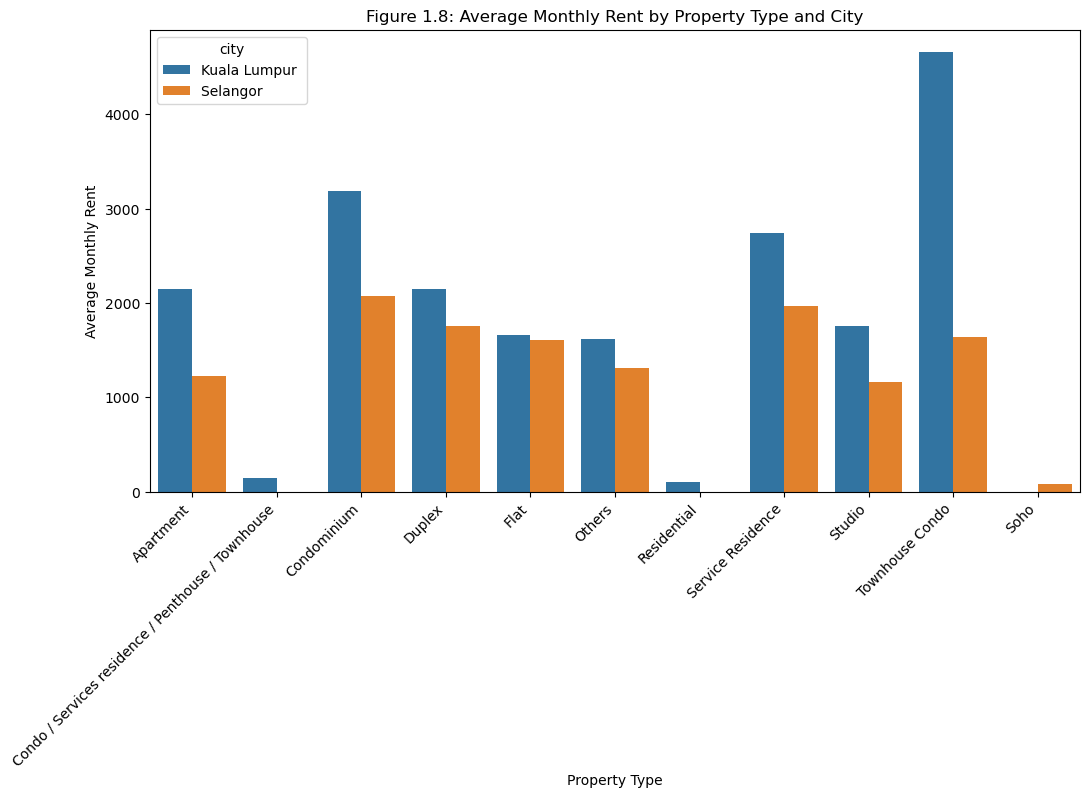

In [15]:
avg_rent = df.groupby(['city', 'property_type'])['monthly_rent'].mean().reset_index(name='AverageRent')

plt.figure(figsize=(12, 6))
sns.barplot(x='property_type', y='AverageRent', hue='city', data=avg_rent)
plt.title('Figure 1.8: Average Monthly Rent by Property Type and City')
plt.xlabel('Property Type')
plt.ylabel('Average Monthly Rent')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Observation
Figure 1.8 shows the comparison of average monthly rent according to property type for Kuala Lumpur and Selangor. Kuala Lumpur generally has a higher average monthly rent compared to Selangor in almost all property type except Soho. Townhouse Condo in Kuala Lumpur clearly stands out with the highest average monthly rent of approximately RM4900, which is significantly higher than Townhouse Condo in Selangor, which has an average monthly rent of approximately RM1900. This property type has the biggest difference in average monthly rent compared to the rest of the property type. 

Condominium in Kuala Lumpur also has a significantly higher average monthly rent of approximately RM3200 than Selangor, which has an average monthly rent of approximately RM2100. However, Condominium is the property type with the highest average monthly rent in Selangor. The property type that has the second highest average monthly rent in Selangor is Service Residence, which average monthly rent of approximately RM2000. Service Residence in Kuala has a slightly higher average monthly rent of approximately RM2900.

Property type such as Residential and Soho has the lowest average monthly in both Kuala Lumpur and Selangor. Residential in Kuala Lumpur has a higher average monthly rent compared to Residential in Selangor. However, Soho in Selangor have a higher average monthly rent compared to Kuala Lumpur.

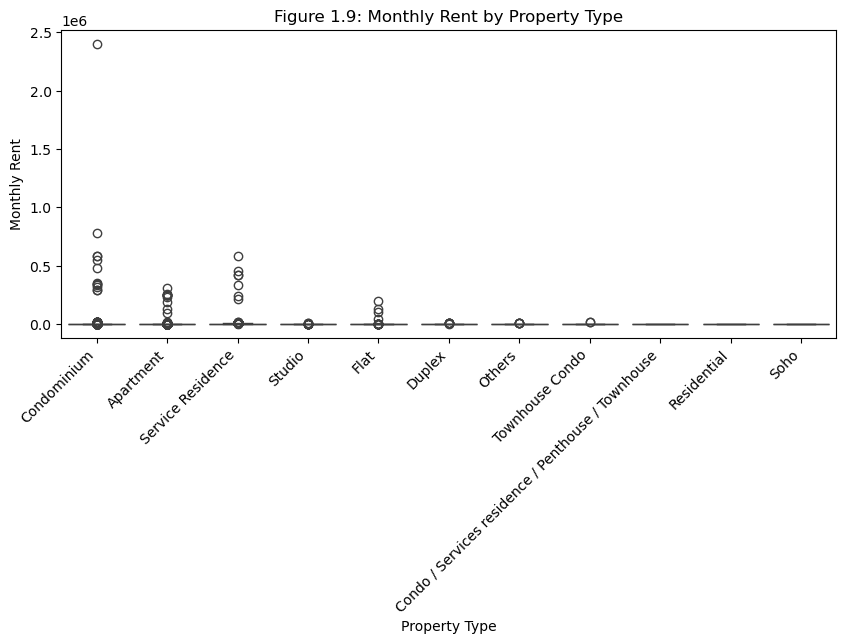

In [16]:
plt.figure(figsize=(10, 4))

sns.boxplot(x='property_type', y='monthly_rent', data = df)
plt.title("Figure 1.9: Monthly Rent by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rent")
plt.xticks(rotation = 45, ha="right")
plt.show()

#### Observation
Based on Figure 1.9, the distribution shows that there are extreme outliers in the dataset which compressses the box for most of the property type. So, we have to perform data cleaning before visualizing our data.

### Data Cleaning

In [17]:
df['monthly_rent'].describe()

count    1.987300e+04
mean     2.271422e+03
std      2.247811e+04
min      7.000000e+01
25%      1.100000e+03
50%      1.400000e+03
75%      1.800000e+03
max      2.400000e+06
Name: monthly_rent, dtype: float64

Based on the output obtained from `df['monthly_rent'].describe()`, it is obvious that `monthly_rent` has extreme values. This is because the *maximum value* for monthly_rent is **2.400000e+06**, which is significantly high compared to the *75th percentile* which is **1.800000e+03**. This highly indicate that there are outliers present in the data set. Hence, we will be using interquartile range (IQR) method to remove the extreme outliers.		

#### Removing outliers

In [18]:
Q1 = df['monthly_rent'].quantile(0.25)
Q3 = df['monthly_rent'].quantile(0.75)
IQR = Q3-Q1
lower_range = Q1 - 1.5 * IQR
upper_range = Q3 + 1.5 * IQR

clean_df_property = df[(df['monthly_rent'] >= lower_range) & (df['monthly_rent'] <= upper_range)]

In [19]:
clean_df_property['monthly_rent'].describe()

count    18609.000000
mean      1443.215756
std        513.368220
min         70.000000
25%       1100.000000
50%       1400.000000
75%       1750.000000
max       2850.000000
Name: monthly_rent, dtype: float64

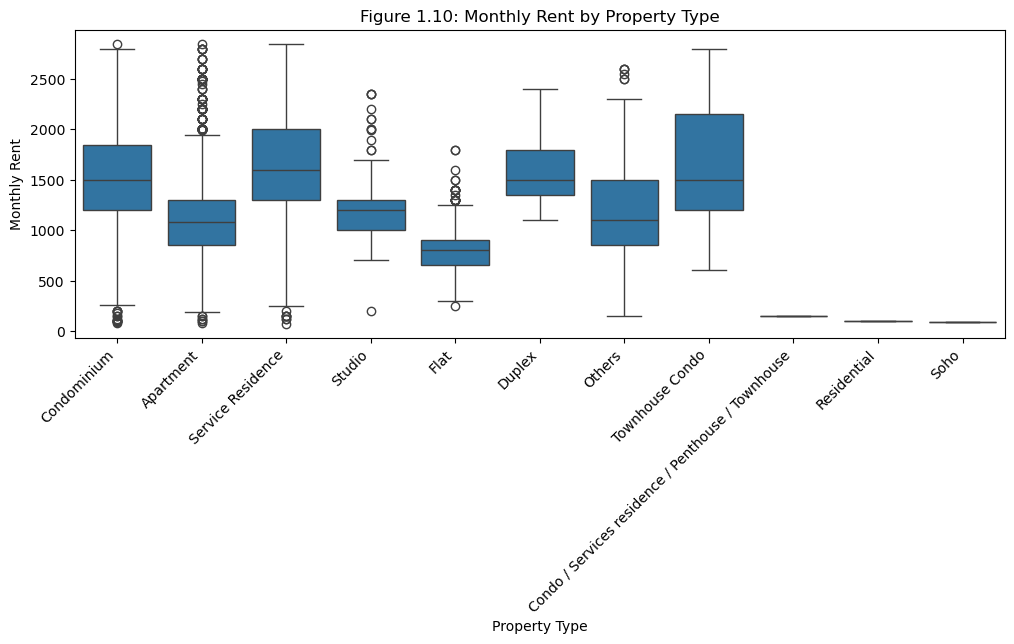

In [20]:
plt.figure(figsize=(12, 4))

sns.boxplot(x='property_type', y='monthly_rent', data = clean_df_property)
plt.title("Figure 1.10: Monthly Rent by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rent")
plt.xticks(rotation = 45, ha="right")
plt.show()

#### Observation
Based on Figure 1.10, after cleaning our dataset, we can see that some of the property type have compressed box. This can be because these property type have very less or zero data after the outliers have been removed. Hence, we will count the number of data these property types have and filter them out if the count is very less.

In [21]:
clean_df_property['property_type'].value_counts()

property_type
Condominium                                           7664
Apartment                                             5201
Service Residence                                     4793
Flat                                                   577
Studio                                                 187
Others                                                  84
Duplex                                                  69
Townhouse Condo                                         31
Condo / Services residence / Penthouse / Townhouse       1
Residential                                              1
Soho                                                     1
Name: count, dtype: int64

As shown by the output above, the count of some property types are only 1. Therefore, we can filter these property types out as they have less significance. 

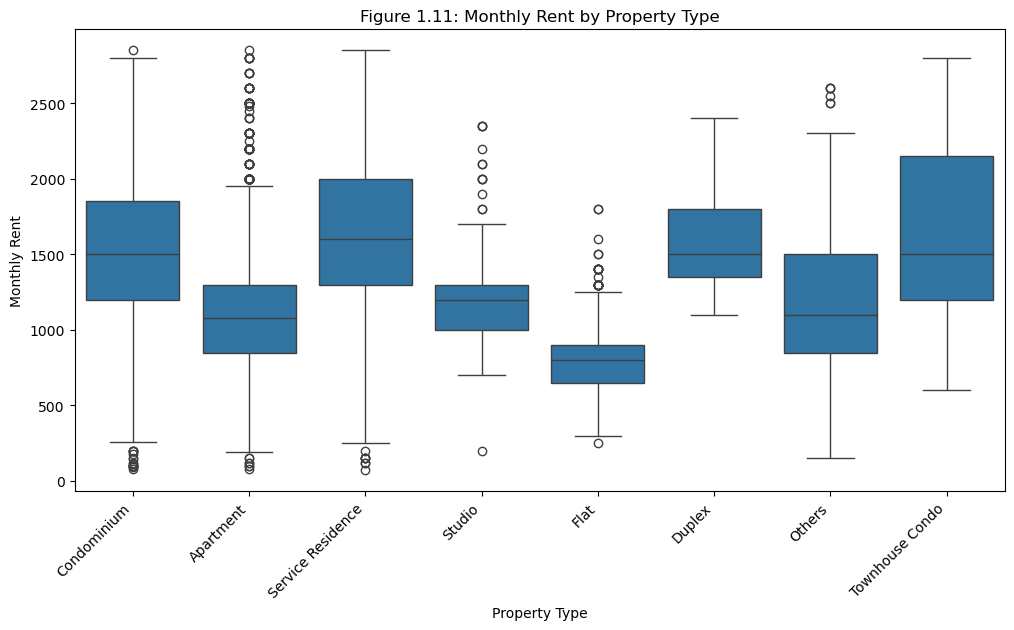

In [22]:
property_count = clean_df_property['property_type'].value_counts()
needed_property_type = property_count[property_count > 5].index
filtered_property = clean_df_property[clean_df_property['property_type'].isin(needed_property_type)]

plt.figure(figsize=(12, 6))

sns.boxplot(x='property_type', y='monthly_rent', data = filtered_property)
plt.title("Figure 1.11: Monthly Rent by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rent")
plt.xticks(rotation = 45, ha="right")
plt.show()

#### Observation
Figure 1.11 shows how rent varies within different property type. Most of the property types have monthly rent between RM1000 and RM2000. Several property types have outliers below and above the whiskers.

**Condominium** shows a relatively wide range of monthly rent, with the median rent around RM1500. There are several outliers below RM500 above RM2500.

**Apartment** have a lower median rent compared to Condominium, around RM1000-RM1100. It also has a significant number of outliers above RM2000.

**Service Residence** has a similar distribution to Condominium. This property type has one of the highest median around RM1500-RM1600 and largest spread.

**Studio** has a smaller monthly rent distribution suggesting that it is more consistently priced. It has a median monthly rent around RM1200.

**Flat** has the lowest median rent, around RM800 compared to all property types. It also has smaller monthly rent distribution compared to most of the property type.

**Duplex** has a median around RM1600. However there are very few to no outliers suggesting that the pricing is more consistent for this property type.

**Others** have a wide range of monthly rent, with the median being relatively in the middle.

**Townhouse Condo** has a median around RM1500. It also has a wide distribution of monthly rent.

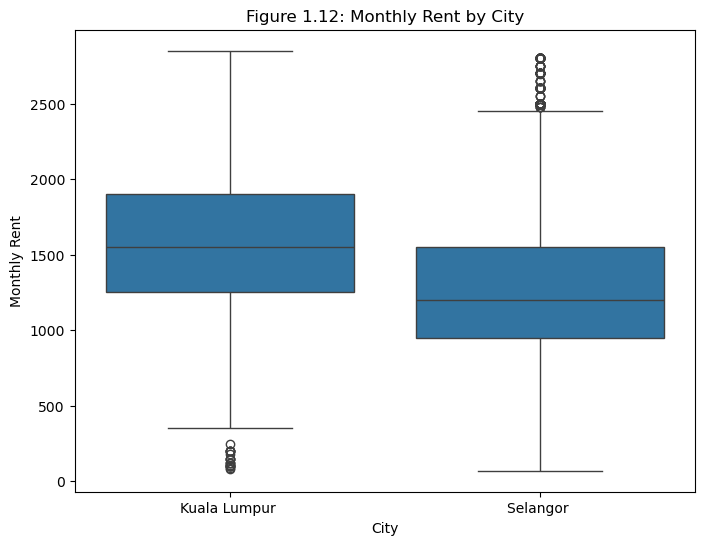

In [23]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='city', y='monthly_rent', data = filtered_property)
plt.title("Figure 1.12: Monthly Rent by City")
plt.xlabel("City")
plt.ylabel("Monthly Rent")
plt.show()

#### Observation
Figure 1.12 shows the distribution of monthly rent by city. Kuala Lumpur has a higher median of monthly rent, which is around RM1550, compared to Selangor, which has median of around RM1200. Kuala Lumpur also has a wider interquartile range compared to Selangor, indicating that Selangor has more consistence in pricing. Kuala Lumpur has more outliers on the low end meanwhile Selangor has more outliers on the high end. 

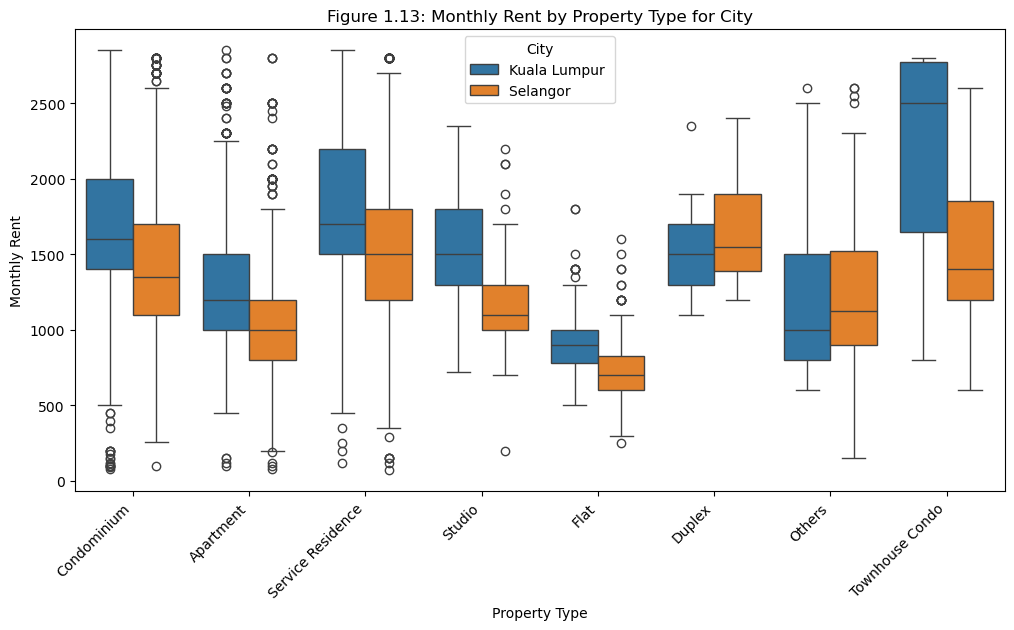

In [24]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='property_type', y='monthly_rent', hue='city', data = filtered_property)
plt.title("Figure 1.13: Monthly Rent by Property Type for City")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rent")
plt.legend(title = 'City')
plt.xticks(rotation = 45, ha="right")
plt.show()

#### Observation
Figure 1.13 shows how monthly rent varies across different property type in different cities. Kuala Lumpur has the higher rents in almost all property type compared to Selangor. However, Duplex in Selangor has higher rent compared to Kuala Lumpur. Townhouse Condo in Kuala Lumpur has the highest rent, with median being close to RM2500, meanwhile Flat in Selangor has the lowest rent, with median beind around RM800. 

Across all property types, Kuala Lumpur tends to show a wider distribution of monthly rent compared to Selangor, especially in Service Residence and Townhouse Condo. Both cities shows significant outliers, especially on Condominium, Apartment and Service Residence.

### Conclusion
This analysis clearly shows that property type is a significant factor influencing monthly rent price within Klang Valley. Among all property types, Condominium, Service Residence and Townhouse Condo have higher average and median monthly rent, compared to Apartments, Studio and Flats. Townhouse Condos shows the highest rental prices, especially in Kuala Lumpur.

Other than that, location by the city, plays a role in monthly rent also. This is because Kuala Lumpur shows higher rental prices across most property type compared to Selangor.

In summary, property type plays a major role in determining monthly rent price. However, monthly rent doesn't solely depend on property type as other factors such as city plays a role.

## **Subquestion 2: How do property size, number of rooms and bathrooms affect to the monthly rent？**
### Jingyuan Yao (Stephanie) - (35595272)

### **Data Preperation**  
Using box plot to visualize the distribution for monthly rent and size, outliers will be removed.

#### **Monthly Rent**

In [25]:
df['monthly_rent'].describe()

count    1.987300e+04
mean     2.271422e+03
std      2.247811e+04
min      7.000000e+01
25%      1.100000e+03
50%      1.400000e+03
75%      1.800000e+03
max      2.400000e+06
Name: monthly_rent, dtype: float64

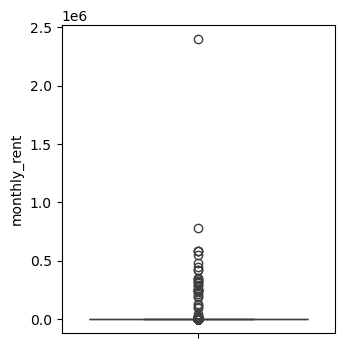

In [26]:
# Box plot for original monthly rent 
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 2)
sns.boxplot(y=df['monthly_rent'])
plt.show()

**Figure 2.1: Monthly rent (original)**

**Observation**  
Based on Figure 2.1 and the output above, the distribution of monthly rent contains some extreme outliers, with a maximum value of 2.4e+06. To improve the visualization, we will remove these excessively high values before plotting.

#### **Size**

In [27]:
df['size'].describe()

count    1.987300e+04
mean     5.952126e+03
std      7.093562e+05
min      1.000000e+00
25%      7.500000e+02
50%      8.880000e+02
75%      1.044000e+03
max      1.000000e+08
Name: size, dtype: float64

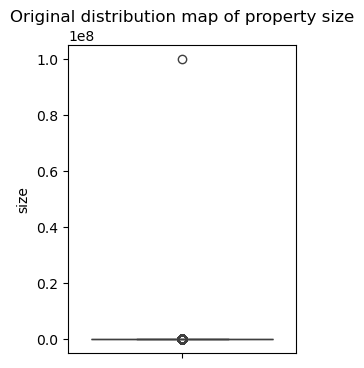

In [28]:
# Box plot for origin property size
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 2)
sns.boxplot(y=df['size'])
plt.title('Original distribution map of property size')
plt.show()

**Figure 2.2: Property size (original)**

**Observation**  
From Figure 2.2 and the output above, the original property size distribution has extreme outliers, with a maximum value of 1e+08 that significantly affects the analysis. Also, the mean (5952.13) is much higher than the median (888), which further indicating the presence of unrealistic size values that need to be cleaned.

**Cleaning**

In [29]:
# Using IQR to remove the outliers
# Monthly rent
Q1_R = df['monthly_rent'].quantile(0.25)
Q3_R = df['monthly_rent'].quantile(0.75)
IQR_R = Q3_R - Q1_R

lower_rent = Q1_R - 1.5 * IQR_R
upper_rent = Q3_R + 5 * IQR_R

print(lower_rent, upper_rent)
# Size
Q1_S = df['size'].quantile(0.25)
Q3_S = df['size'].quantile(0.75)
IQR_S = Q3_S - Q1_S

lower_size = Q1_S - 1.5 * IQR_S
upper_size = Q3_S + 5 * IQR_S

print(lower_size,upper_size)

50.0 5300.0
309.0 2514.0


In [30]:
# missing value
df_clean = df.dropna(subset=['monthly_rent', 'size', 'rooms', 'bathroom'])

# Remove outliers for monthly rent and size
df_cleaned = df_clean[
    (df_clean['monthly_rent'] >= lower_rent) & (df_clean['monthly_rent'] < 6000) &
    (df_clean['size'] >= lower_size) & (df_clean['size'] <= 2500)
]

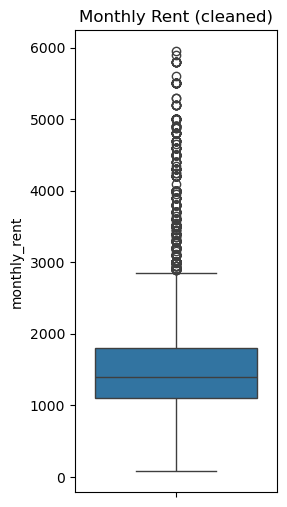

In [31]:
# Plots after cleaning - monthly rent
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 2)
sns.boxplot(y=df_cleaned['monthly_rent'])
plt.title('Monthly Rent (cleaned)')
plt.show()

**Figure 2.3: Monthly rent (cleaned)**

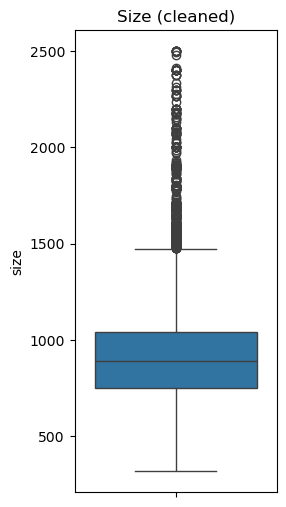

In [32]:
# Plots after cleaning - size
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 2)
sns.boxplot(y=df_cleaned['size'])
plt.title('Size (cleaned)')
plt.show()

**Figure 2.4: Property size (cleaned)**

### To increase the accuracy of the analysis and to focus on the major portion of the dataset, following steps were taken:
- Remove missing values from the key variable (monthly rent and size)
- Filter extreme values based on resonable limits
  - monthly rent: between RM 200 – RM 6,000
  - size: between 300 – 2,500 sqft
 
Box plots (Figure 2.3, Figure 2.4) were used to visualize the data distributions before and after cleaning, ensuring the value's range is resonable.

### **2. Basic distribution of monthly rent, size , rooms, and bathroom**

In [33]:
# Monthly rent (Cleaned)
df_cleaned['monthly_rent'].describe()

count    19466.000000
mean      1572.816655
std        721.953294
min         80.000000
25%       1100.000000
50%       1400.000000
75%       1800.000000
max       5950.000000
Name: monthly_rent, dtype: float64

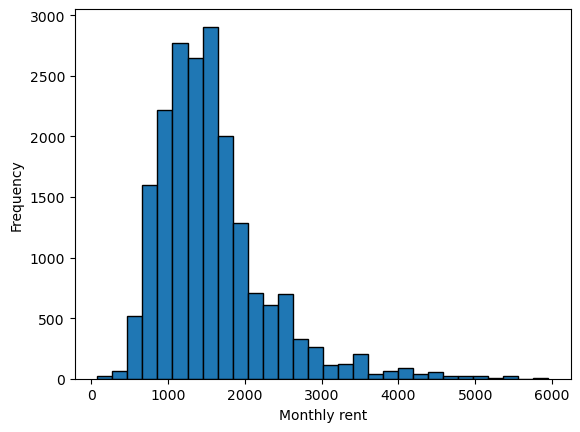

In [34]:
# Scatter plot for distributionof monthly rent
plt.hist(df_cleaned['monthly_rent'], bins=30, edgecolor='black')
plt.xlabel('Monthly rent')
plt.ylabel('Frequency')
plt.show()

**Figure 2.5: Distribution of Monthly Rent**

**Observation**  
From above data description and figure 2.5, for selected data, the mean of monthly rent is about RM 1,573, the median is RM 1400. Most properties have a monthly rent ranging from RM 500 to RM 2000. Additionally, 75% of the properties have rent below RM 1,800. Properties with rent above RM 3000 are very rare.

In [35]:
# Size (Cleaned)
df_cleaned['size'].describe()

count    19466.000000
mean       911.390938
std        264.633836
min        320.000000
25%        750.000000
50%        890.000000
75%       1040.000000
max       2500.000000
Name: size, dtype: float64

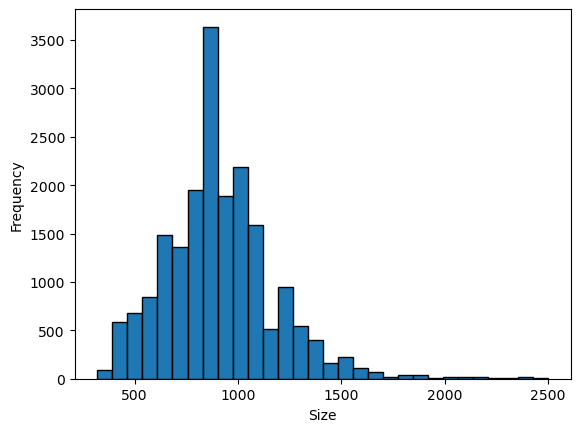

In [36]:
# Scatter plot for distributionof monthly rent
plt.hist(df_cleaned['size'], bins=30, edgecolor='black')
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.show()

**Figure 2.6: Distribution of property size**

**Observation**  
From above data description and figure 2.6, the distribution shows that the size of these properties are mostly in range of 500-1250 sqft, the mean of selected range properties' size is about 909.66 sqft, the median is 889 sqft. Additionally, 75% of the properties are smaller than 1,039 sqft, and properties larger than 1,500 sqft are quite rare.

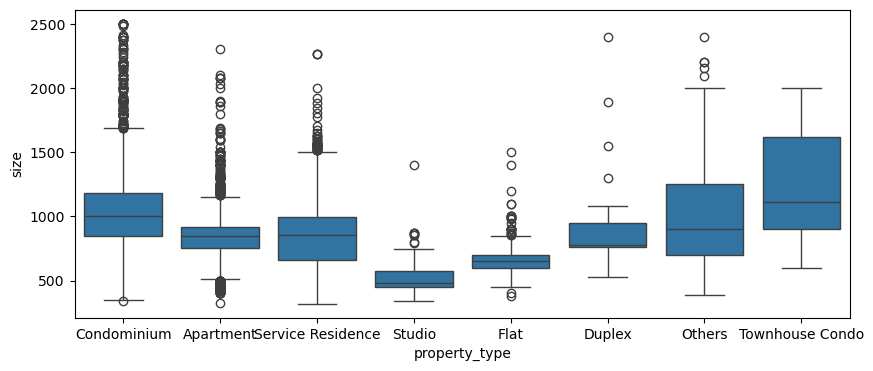

In [37]:
# Size distribution by property type
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_cleaned, x='property_type', y='size')
plt.show()

**Figure 2.7. Size Distribution by Property Type**

**Observation**  
From the abve box plot (figure 2.3), the median of size for condominium and townhouse condo are around 1000 sqft, which tend to have larger size than other property types. Studio shows the lowest size range, under 600 sqft, flat is second low. Other property types shows their main size range is between 600-1000 sqft.

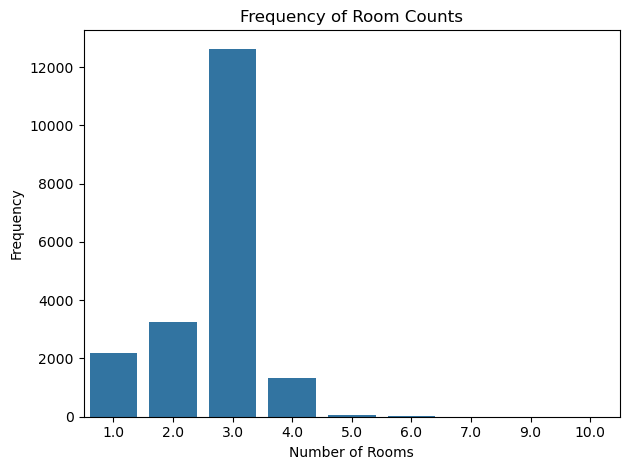

In [38]:
# Distribution of Room Counts
room_counts = df_cleaned['rooms'].value_counts().sort_index()

# scatter plot
sns.countplot(data=df_cleaned, x='rooms', order=sorted(df_cleaned['rooms'].dropna().unique()))
plt.title('Frequency of Room Counts')
plt.xlabel('Number of Rooms')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Figure 2.7: Frequency of Rooms**

**Observation**  
Figure 2.7 shows that over 12,000 properties have 3 rooms, accounting for almost 60% of the total in this dataset. This is followed by properties with 2 rooms (around 3,000), 1 room (approximately 2,000), and 4 rooms (fewer than 2,000). Properties with 5 or more rooms are very rare.

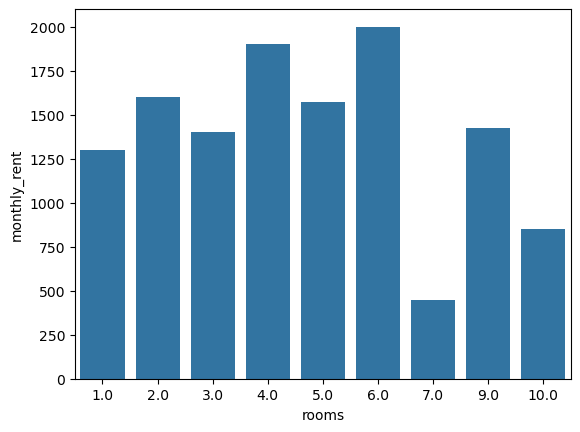

In [39]:
## Median monthly rent for each rooms counts
median_rent_by_room = df_cleaned.groupby('rooms')['monthly_rent'].median().reset_index()
sns.barplot(data=median_rent_by_room, x='rooms', y='monthly_rent')
plt.show()

**Figure 2.8: Median Rent by Rooms Count**

**Observation**  
However, the median of monthly rent for each rooms counts (Figure 2.8) shows that properties with 4 and 6 rooms have higher rent, which suggests that the monthly rent does not show a linear positive correlation with the rooms count.

In [40]:
# The number of properties for each number of bathrooms
bathroom_counts = df_cleaned['bathroom'].value_counts().sort_index()
bathroom_counts_df = bathroom_counts.reset_index()
bathroom_counts_df.columns = ['Bathrooms', 'Number of Properties']
bathroom_counts_df

,Bathrooms,Number of Properties
0,1.0,3591
1,2.0,14717
2,3.0,1028
3,4.0,112
4,5.0,16
5,6.0,1
6,8.0,1


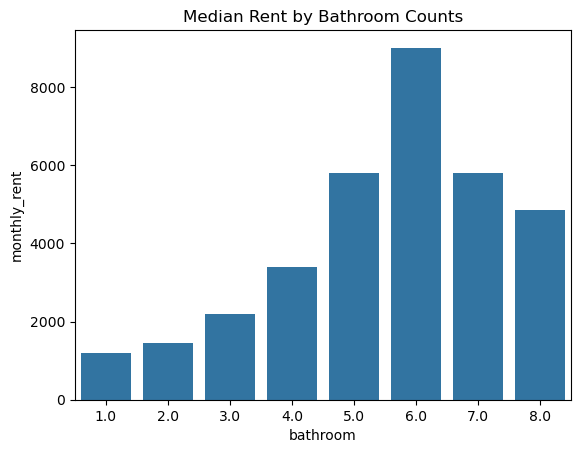

In [41]:
## Median monthly rent for each bathroom counts
median_rent_bathroom = df.groupby('bathroom')['monthly_rent'].median().reset_index()
sns.barplot(data=median_rent_bathroom, x='bathroom', y='monthly_rent')
plt.title('Median Rent by Bathroom Counts')
plt.show()

**Figure 2.9: Median Rent by Bathroom Counts**

**Observation**  
Figure 2.9 shows that properties with more bathrooms generally tend to have higher monthly rent. However, when the number of bathrooms exceeds 5, this trend no longer holds. Notably, properties with 8 bathrooms exhibit unexpectedly low rent, deviating significantly from the overall pattern. As observed earlier, this may be due to the very small sample size—only one property has 8 bathrooms and another has 6, which makes these data points less reliable and potentially unrealistic.

### **3. Correlation Analysis Among Size, Rooms, Bathroom, and Monthly Rent**

#### **The Relationship Between Property Size and Monthly Rent**

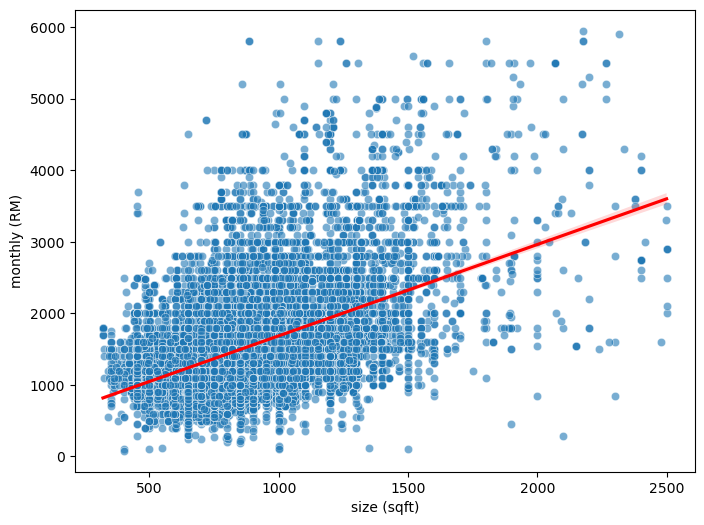

In [42]:
# Size vs Monthly rent
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x='size', y='monthly_rent', alpha=0.6)
sns.regplot(data=df_cleaned, x='size', y='monthly_rent', scatter=False, color='red') # Add trend line

plt.xlabel("size (sqft)")
plt.ylabel("monthly (RM)")
plt.show()

**Figure 2.10: Size vs Monthly rent**

From the tend line of this scatter plots above (figure 2.10), the monthly rent is generally positively correlated with the size of the properties, but the tend of the spots is not very obvious.

#### **Correlation Among Property Size, Rooms, bathrooms, and Monthly Rent**

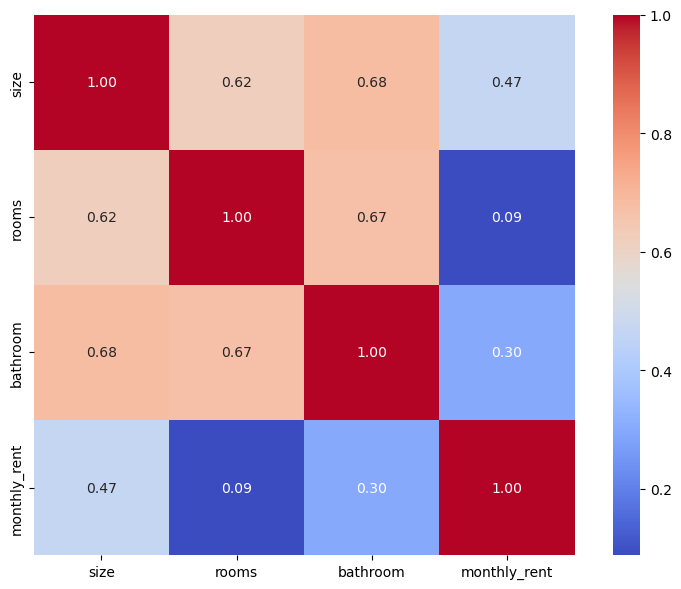

In [43]:
corr_vars = ['size', 'rooms', 'bathroom', 'monthly_rent']

# correlation heatmap
corr_matrix = df_cleaned[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.tight_layout()
plt.show()

**Figure 2.11: Correlation Heatmap: Size, Rooms, Bathroom, Monthly_rent**

**Observation**  
The heatmap for `size`, `rooms`, `bathroom` and `monthly rent` (figure 3.2) indicates that `size` has a moderate positive correlation with `monthly rent` (r=0.45), `bathroom` count also shows a moderate positive correlation with `monthly rent` (r=0.28), which means properties with larger size and more bathrooms tend to have higher monthly rent. The property `size` and `rooms` count shows an expected strong positive correlation as larger properties typically have more rooms. Howerver `rooms` count has a very weak correlation with the `monthly rent` (r=0.07), this suggest that rooms count alone cannot efficiently predict the property rental prices.

### **Conclusion**  
While property size, rooms, and bathroom count all positively affect monthly rent, size is the most important factor and bathroom count followed, but size is not enough on its own to accurately predict rent.

## **Subquestion 3: How furnishing status impact monthly rent?**
### Leng Jaek-Hxiang - (35897317)

#### RELATIONSHIP BETWEEN PROPERTY FURNISH STATUS AND MONTHLY RENT

In [44]:
# Eliminate nan value
unique_furnish = df['furnished'].dropna().unique()

# Understand the furnish status of properties
print("Furnished status of properties:")
for furnish in unique_furnish:
    print(furnish)

Furnished status of properties:
Fully Furnished
Partially Furnished
Not Furnished


In [45]:
# Understand the number of properties for each furnish status
value_counts = df['furnished'].value_counts()
print("Furnish status and their number of properties",value_counts)

Furnish status and their number of properties furnished
Fully Furnished        8388
Partially Furnished    7967
Not Furnished          3515
Name: count, dtype: int64


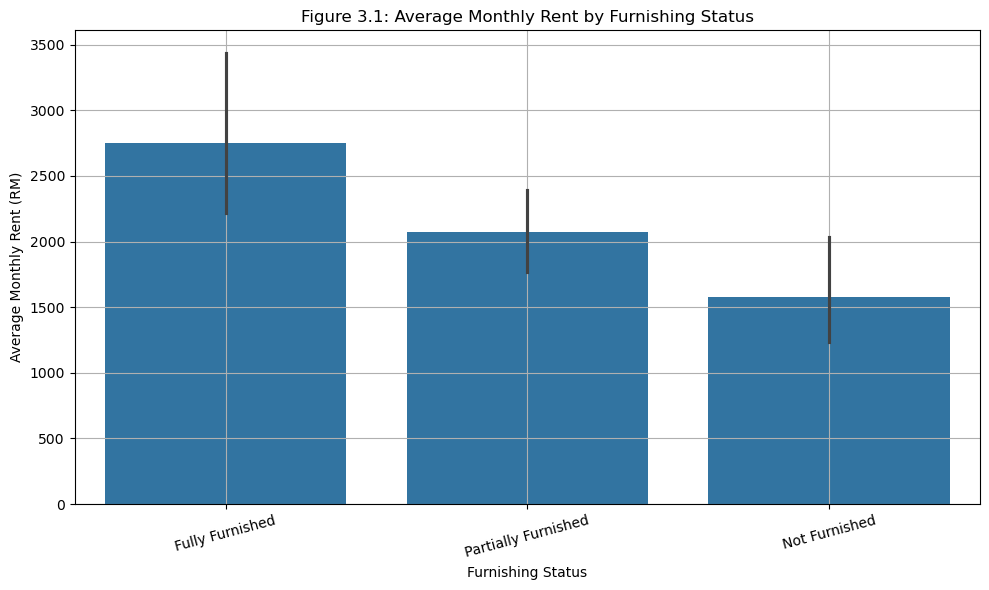

In [46]:
# Drop rows with missing values in 'furnished' or 'monthly_rent'
df_clean = df.dropna(subset=['furnished', 'monthly_rent'])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='furnished', y='monthly_rent', data=df_clean)
plt.title('Figure 3.1: Average Monthly Rent by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Monthly Rent (RM)')

# Adjust y-axis formatting to display numbers in a more readable way
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

# Rotate x-axis labels and show grid
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.show()

##### Figure 3.1: The average monthly rent of properties with three different furnishing status, with error bars representing ± standard deviation(SD) of all replicates in each population.

Based on figure 3.1, fully furnished properties have the highest monthly rent while the not furnished properties have the lowest monthly rent, with partially furnished properties are in the middle range. The average monthly rent for fully furnished properties are about RM2700, while partially furnished properties are about RM2000 and not furnished properties are about RM1500.

##### Conclusion:
The more furnished a property is, the higher the average monthly rent tends to be.

#### RELATIONSHIP BETWEEN FURNISHED STATUS AND CITY ON MONTHLY RENT

In [47]:
# Drop rows with missing values in 'furnished' or 'monthly_rent'
unique_cities = df['city'].dropna().unique()

print("Cities in the dataset:")
for city in unique_cities:
    print(city)

Cities in the dataset:
Kuala Lumpur 
Selangor 


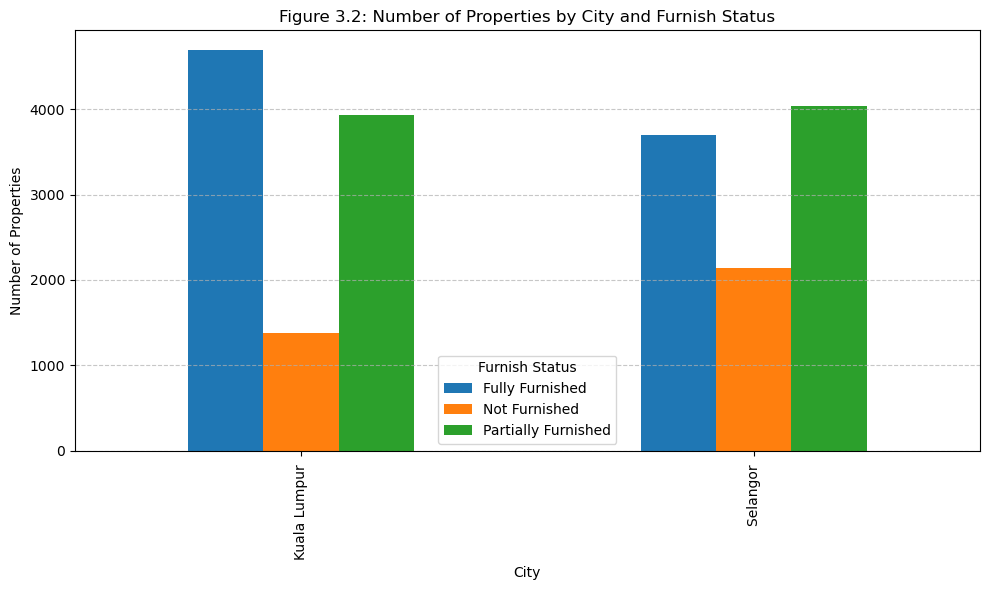

In [48]:
# this is to understand the trend of furnish status of properties in different cities
# Group by 'City' and 'Furnish Status' and count the number of properties
grouped = df_clean.groupby(['city', 'furnished']).size().unstack(fill_value=0)

# Plot a grouped bar chart
grouped.plot(kind='bar', figsize=(10, 6))

# Set labels and title
plt.title('Figure 3.2: Number of Properties by City and Furnish Status')
plt.xlabel('City')
plt.ylabel('Number of Properties')
plt.legend(title='Furnish Status')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

##### Figure 3.2:The number of properties based on different cities and furnish status.
Based on  figure 3.2, property owners in Kuala Lumpur are more likely to fully furnish their properties compared to Selangor. In contrast, property owners in Selangor are more likely to partially furnish or not furnish their properties.

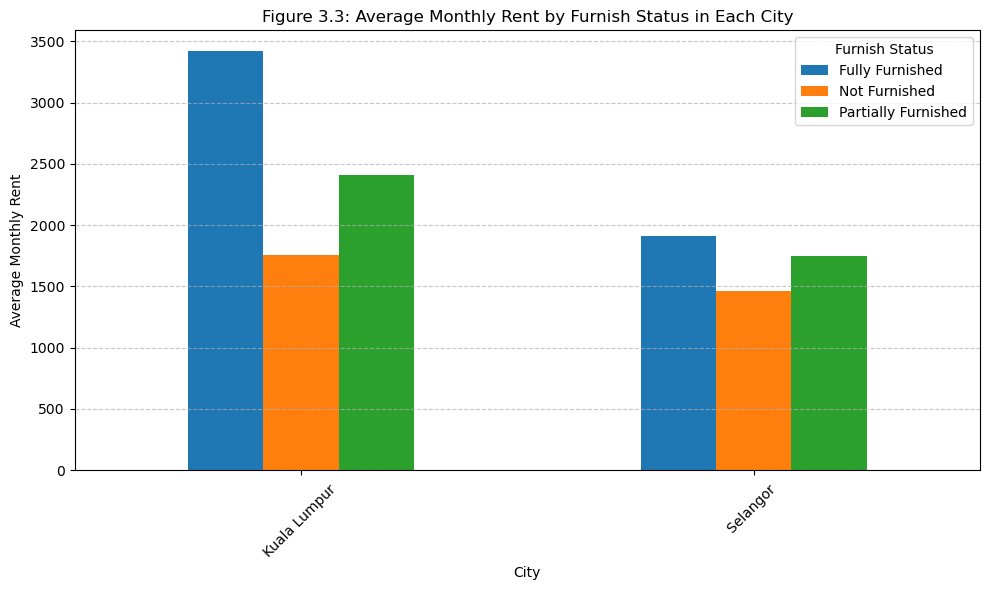

In [49]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop rows with missing values in key columns
df_clean = df[['city', 'furnished', 'monthly_rent']].dropna()

# Group by both City and Furnished to get average rent
grouped = df_clean.groupby(['city', 'furnished'])['monthly_rent'].mean().unstack()

# Plot grouped bar chart
grouped.plot(kind='bar', figsize=(10, 6))

# Labeling
plt.title('Figure 3.3: Average Monthly Rent by Furnish Status in Each City')
plt.xlabel('City')
plt.ylabel('Average Monthly Rent')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Furnish Status')

# Layout adjustment
plt.tight_layout()
plt.show()

##### Figure 3.3: The average monthly rent of different furnish status in two cities.
Based on figure 3.3, for fully furnished properties, those in Kuala Lumpur tend to have a significantly higher average monthly rent compared to those in Selangor. In contrast, unfurnished properties in both Kuala Lumpur and Selangor appear to have roughly the same average monthly rent. Lastly, partially furnished properties in Kuala Lumpur have a moderately higher average monthly rent than those in Selangor.

##### Conclusion:
Fully furnished properties in Kuala Lumpur command significantly higher rents compared to those in Selangor, indicating a stronger market demand or higher living costs in the city. However, for unfurnished properties, the rent prices remain relatively consistent between the two locations. Partially furnished properties in Kuala Lumpur also show moderately higher rents, reinforcing the pattern that added furnishing contributes to higher rental value, especially in urban areas like Kuala Lumpur.

#### RELATIONSHIP BETWEEN COMPLETION YEAR AND MONTHLY RENT

In [50]:
# Understand the completion year of all the properties
property_completion_year = df['completion_year'].unique().tolist()
print(property_completion_year)

[2022.0, nan, 2020.0, 2018.0, 2014.0, 2019.0, 2017.0, 2021.0, 2006.0, 2015.0, 1999.0, 2004.0, 2007.0, 2002.0, 1985.0, 2010.0, 2012.0, 1988.0, 1998.0, 2023.0, 1990.0, 2016.0, 2003.0, 2000.0, 2008.0, 1995.0, 2013.0, 2011.0, 1994.0, 2009.0, 1996.0, 2005.0, 1993.0, 1997.0, 2001.0, 2025.0, 1980.0, 1989.0, 1987.0, 1984.0, 2024.0, 1991.0, 1977.0]


In [51]:
# Group by 'Completion Year' and count the number of properties for each year
property_count = df.groupby('completion_year').size()

# Sort the result by 'Completion Year' in descending order
property_count_sorted = property_count.sort_index(ascending=False)

# Convert the result to a DataFrame for better presentation
property_count_df = property_count_sorted.reset_index(name='Number of Properties')

# Display the sorted result
print(property_count_df)

    completion_year  Number of Properties
0            2025.0                    29
1            2024.0                    10
2            2023.0                   192
3            2022.0                   507
4            2021.0                  1298
5            2020.0                   997
6            2019.0                   768
7            2018.0                   804
8            2017.0                   896
9            2016.0                   680
10           2015.0                   806
11           2014.0                   560
12           2013.0                   461
13           2012.0                   131
14           2011.0                   152
15           2010.0                   334
16           2009.0                   163
17           2008.0                   216
18           2007.0                   348
19           2006.0                   240
20           2005.0                   182
21           2004.0                   166
22           2003.0               

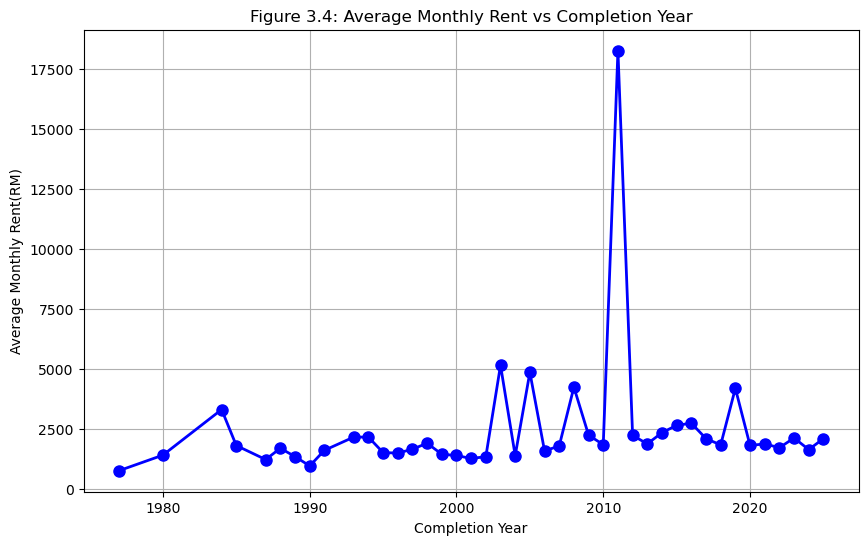

In [52]:
# Drop rows with missing values in 'furnished' or 'monthly_rent'
df_clean = df.dropna(subset=['completion_year', 'monthly_rent'])

# Calculate the average monthly rent for each Completion Year
avg_rent_by_year = df.groupby('completion_year')['monthly_rent'].mean()

# Sort by Completion Year in descending order (optional)
avg_rent_by_year_sorted = avg_rent_by_year.sort_index(ascending=False)

# Plot the line graph
plt.figure(figsize=(10, 6))
plt.plot(avg_rent_by_year_sorted.index, avg_rent_by_year_sorted.values, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)

# Set labels and title
plt.xlabel('Completion Year')
plt.ylabel('Average Monthly Rent(RM)')
plt.title('Figure 3.4: Average Monthly Rent vs Completion Year')

# Display the plot
plt.grid(True)
plt.show()

##### Figure 3.4: Average monthly rent of properties based on their completion year.
Based on figure 3.4, the average monthly rent is increasing slowly as the completion year of the property increased. However, there are several outliers causing the graph to spike and affecting the visualisation of the general trend.

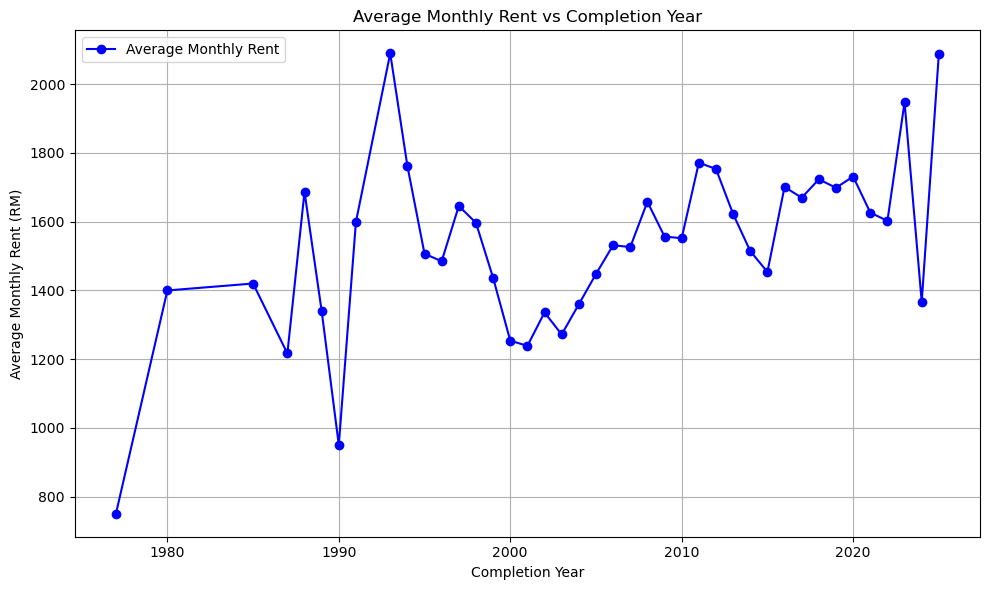

In [53]:
# Drop missing values
df_clean = df.dropna(subset=['completion_year', 'monthly_rent'])

# Remove outliers using IQR
Q1 = df_clean['monthly_rent'].quantile(0.25)
Q3 = df_clean['monthly_rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_clean[(df_clean['monthly_rent'] >= lower_bound) & (df_clean['monthly_rent'] <= upper_bound)]

# Group by completion year and calculate average rent
avg_rent_by_year = df_filtered.groupby('completion_year')['monthly_rent'].mean()
avg_rent_by_year_sorted = avg_rent_by_year.sort_index()


# Plot average rent line
plt.figure(figsize=(10, 6))
plt.plot(avg_rent_by_year_sorted.index, avg_rent_by_year_sorted.values, marker='o', linestyle='-', color='blue', label='Average Monthly Rent')


# Title and labels
plt.title('Average Monthly Rent vs Completion Year')
plt.xlabel('Completion Year')
plt.ylabel('Average Monthly Rent (RM)')
plt.grid(True)

# Add legend
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

##### Figure 3.5 Average monthly rent based on their completion year(without extreme values).
Based on Figure X, the average monthly rent of properties completed before the year 2000 shows noticeable fluctuations, whereas properties completed after 2000 exhibit a more stable and consistent upward trend.

## **Subquestion 4: Do special facilities influence the rent of the house?**
### Jayson Yu Hanjie - (35569557)

In [55]:
# Define special facility keywords，assume swimming pool and gymasium as special facility
special_facilities_keywords = ['Swimming Pool', 'Gymnasium']

In [56]:
# Create a column to indicate if the property has special facilities
df['has_special_facilities'] = df['facilities'].fillna('').apply(
    lambda x: any(keyword in x for keyword in special_facilities_keywords)
)

In [57]:
# Show rental price comparison (summary statistics)
comparison = df.groupby('has_special_facilities')['monthly_rent'].describe()

In [58]:
# Prepare data for plotting (filter out extreme values for clearer plots)
df_filtered = df[df['monthly_rent'] < 10000]

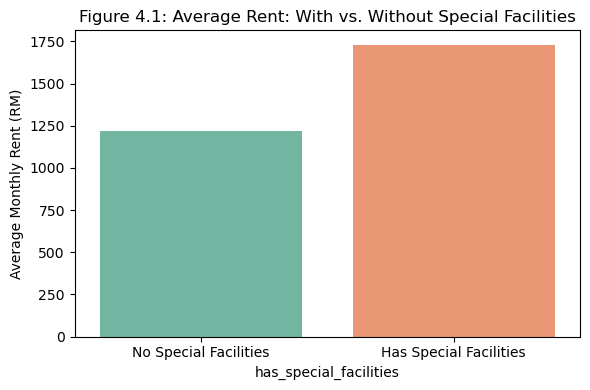

In [59]:
# Step 7: Bar plot for average rent
plt.figure(figsize=(6, 4))
avg_rent = df_filtered.groupby('has_special_facilities')['monthly_rent'].mean().reset_index()
sns.barplot(data=avg_rent, x='has_special_facilities', y='monthly_rent',hue='has_special_facilities', palette='Set2',legend=False)
plt.xticks([0, 1], ['No Special Facilities', 'Has Special Facilities'])
plt.ylabel('Average Monthly Rent (RM)')
plt.title('Figure 4.1: Average Rent: With vs. Without Special Facilities')
plt.tight_layout()
plt.show()

**Observation**

From figure 1: Firstly we define gyms and swimming pool as special facilities, it can be every facility, we choose random from dataset. The aim for this step is to approve the special facilities can influence the rent of houses, no matter what facility is it.<br> We observe that the average monthly rent is higher for properties with facilities compred to those without.
specifically, properties with special facilities have an average rent close to RM1700, while those without special facilites 
have an average rent of approximately RM1200. This suggests that the presence of special facilities may significantly increase
that rental cost.

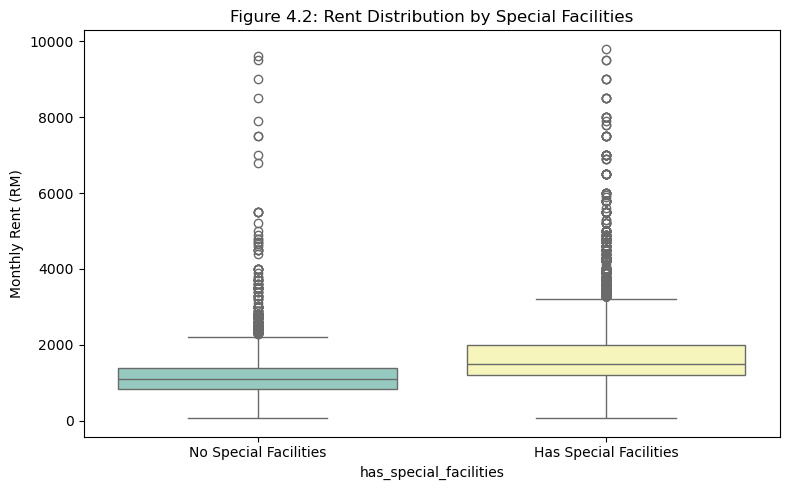

In [60]:
# Box plot for rent distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filtered, x='has_special_facilities', y='monthly_rent',hue='has_special_facilities', palette='Set3',legend=False)
plt.xticks([0, 1], ['No Special Facilities', 'Has Special Facilities'])
plt.ylabel('Monthly Rent (RM)')
plt.title('Figure 4.2: Rent Distribution by Special Facilities')
plt.tight_layout()
plt.show()

**Observation**

Based on Figure 4.2, there is a clear distinction in the rent distributions between properties with and without special facilities. Firstly, the median rent is higher for properties that offer special facilities, as indicated by the central line in the box plot. This aligns with earlier observations from the bar chart, which suggested that such properties generally charge more. In terms of variability, properties with special facilities display a wider interquartile range (IQR), indicating greater dispersion in rental prices. In contrast, those without special facilities have a narrower IQR, reflecting more consistent pricing. Outliers are present in both groups, particularly above RM 3000; however, the “Has Special Facilities” group exhibits more frequent and extreme outliers, with some rents approaching RM 10,000. This suggests that certain high-end properties with special features charge exceptionally high rents. Lastly, the distribution of rent values for properties with special facilities appears positively skewed, with the box shifted upwards, implying that while many rents fall in the mid-range, a substantial number are significantly higher.

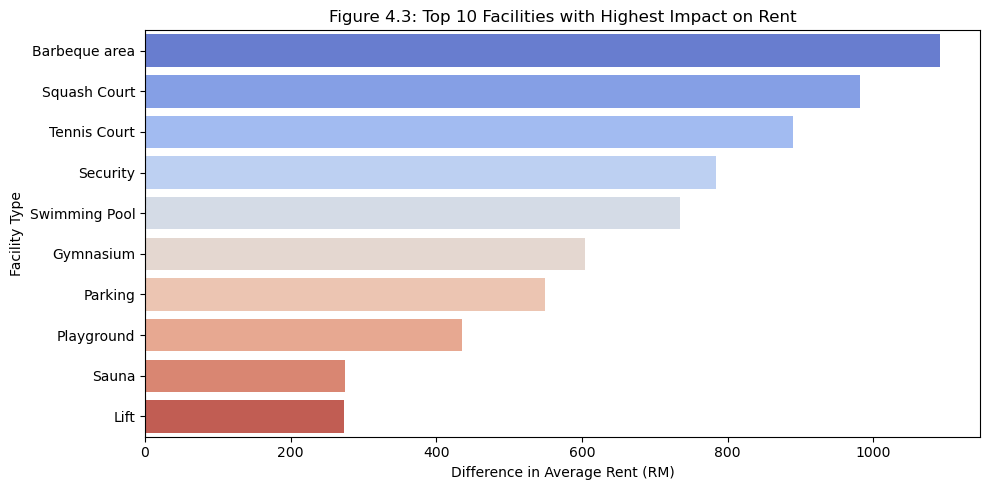

In [61]:
# First, get unique facilities (you need to define this properly)
# Assuming 'facilities' column contains strings with multiple facilities separated by some delimiter
unique_facilities = set()
df['facilities'].fillna('').str.split(',').apply(lambda x: [unique_facilities.add(i.strip()) for i in x if i.strip()])
unique_facilities = list(unique_facilities)  # Convert to list

# Step 2: Add a column for each facility (True/False)
for fac in unique_facilities:  # Fixed variable name (no space)
    df[fac] = df['facilities'].fillna('').apply(lambda x: fac in x)

# Step 3: Compare rent with vs. without each facility
facility_rent_summary = {}
for fac in unique_facilities:  # Fixed variable name here too
    with_fac = df[df[fac]]['monthly_rent']
    without_fac = df[~df[fac]]['monthly_rent']  # Also fixed the negation operator (use ~ instead of -)
    facility_rent_summary[fac] = {
        'with_facility_mean': with_fac.mean(),
        'without_facility_mean': without_fac.mean(),
        'diff': with_fac.mean() - without_fac.mean()
    }

# Step 4: Compare rent with vs. without each facility
facility_rent_summary = {}
for fac in unique_facilities:
    with_fac = df[df[fac]]['monthly_rent']
    without_fac = df[~df[fac]]['monthly_rent']
    facility_rent_summary[fac] = {
        'with_facility_mean': with_fac.mean(),
        'without_facility_mean': without_fac.mean(),
        'diff': with_fac.mean() - without_fac.mean()
    }

# Step 5: Create summary DataFrame
facility_rent_df = pd.DataFrame(facility_rent_summary).T.sort_values(by='diff', ascending=False)

# Step 6: Plot Top 10 impactful facilities
top_facilities = facility_rent_df.head(10).reset_index()
top_facilities.rename(columns={'index': 'facility'}, inplace=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_facilities, x='diff', y='facility',hue='facility', palette='coolwarm', legend=False )
plt.xlabel('Difference in Average Rent (RM)')
plt.ylabel('Facility Type')
plt.title('Figure 4.3: Top 10 Facilities with Highest Impact on Rent')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

**Observation**  
Trend and Key Insights for Figure 4.3:
1. Luxury or Lifestyle Facilities Have Higher Impact:
- Barbeque area has the strongest influence, increasing rent by nearly RM 1,000.
- Squash Court and Tennis Court also contribute significantly to higher rents.
- These are considered lifestyle or premium amenities that appeal to higher-income tenants.
2. Security and Swimming Pool also show a moderate impact on rent.
- These are desirable but more common facilities.  
3. Basic or Essential Facilities Have Less Impact:
- Gymnasium, Parking, Playground, and Lift have lower effects on rent.
- Even though they are important, they are standard in many buildings, so they don’t drive rental prices as much.

**Conclusion:**  
The presence of premium and recreational facilities has a notable impact on increasing rental prices, as they are perceived as value-adding features by tenants. In contrast, essential amenities such as lifts and parking are generally expected in modern residential properties and therefore do not significantly influence rent levels. This pattern suggests that high-income tenants are not merely seeking functional living spaces, but are also willing to pay more for luxury and leisure-oriented amenities that enhance their lifestyle and overall living experience.

## **Subquestion 5: Do rental prices vary across different cities & areas in the data set**
### Wenqi Yang - (35279850)

In [62]:
#clean the missing data
df_clean = df.dropna(subset=['monthly_rent'])

#clean the extreme values
q1 = df_clean['monthly_rent'].quantile(0.001)
q99 = df_clean['monthly_rent'].quantile(0.999)
print(f"0.1% Quantile: {q1}, 99.9% Quantile: {q99}")

df_clean = df_clean[(df_clean['monthly_rent'] >= q1) & 
                    (df_clean['monthly_rent'] <= q99)]

0.1% Quantile: 149.36, 99.9% Quantile: 251280.0000000061


In [63]:
#catagorize data by city
cities = ['Kuala Lumpur ', 'Selangor ']
df_cities = df_clean[df_clean['city'].isin(cities)]

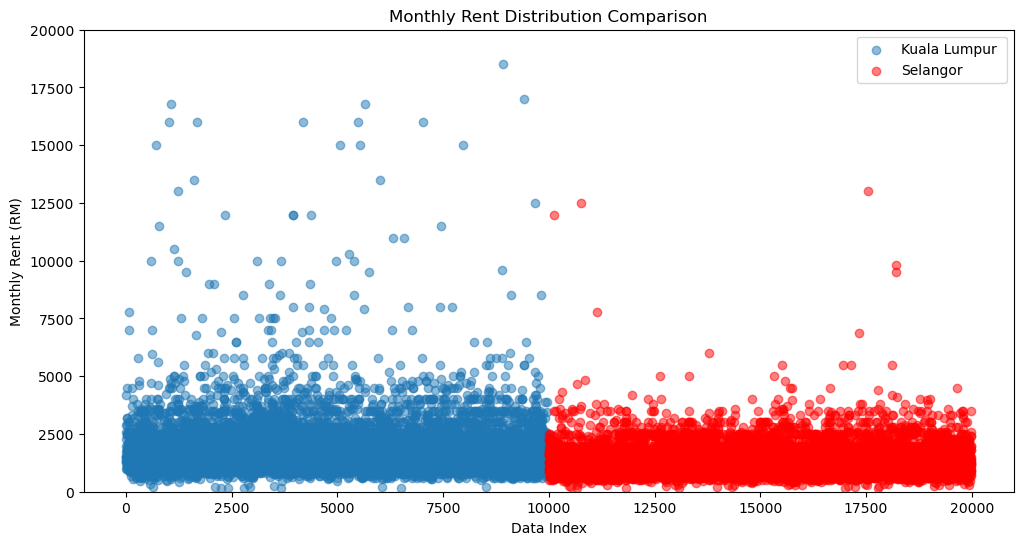

In [64]:
#draw the scatter plot of each city
plt.figure(figsize=(12, 6))
kl_data = df_cities[df_cities['city'] == 'Kuala Lumpur ']
sgor_data = df_cities[df_cities['city'] == 'Selangor ']

#for the data of Kuala Lumpour
df_cities[df_cities['city'] == 'Kuala Lumpur ']
plt.scatter(kl_data.index, kl_data['monthly_rent'], alpha=0.5, label='Kuala Lumpur ')

#for the data of Selangor
df_cities[df_cities['city'] == 'Selangor ']
plt.scatter(sgor_data.index, sgor_data['monthly_rent'], alpha=0.5, color='red', label='Selangor')
plt.ylim(0, 20000)
plt.title('Monthly Rent Distribution Comparison')
plt.xlabel('Data Index')
plt.ylabel('Monthly Rent (RM)')
plt.legend()
plt.show()

#### Figure 5.1. Scatter plot of the rent distribution in two cities: Kuala Lumpur and Selangor.

**Observation**

From Figure 5.1, we can see that although most of the rents in the two cities are concentrated in the lower price range below 2,500RM, the number of samples of rents in Kuala Lumpur is higher because there are more high-price marks in the figure. Also, the highest rent in the two cities is about 1,800RM from Kuala Lumpur, while the highest one in Selangor is about 1,300RM.

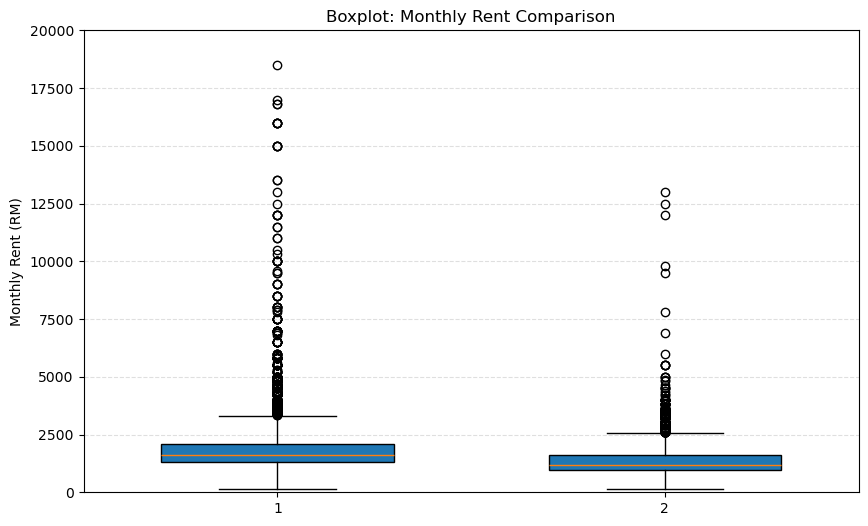

In [65]:
plt.figure(figsize=(10, 6))

data_to_plot = [
    df_cities[df_cities['city'] == 'Kuala Lumpur ']['monthly_rent'],
    df_cities[df_cities['city'] == 'Selangor ']['monthly_rent']
]

#draw the boxplot by different city
plt.boxplot(
    data_to_plot,
    patch_artist=True,
    widths=0.6
)

plt.ylim(0, 20000)  #keep the same of ylim of the two cities
plt.title('Boxplot: Monthly Rent Comparison')
plt.ylabel('Monthly Rent (RM)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

#### Figure 5.2. is a box plot comparing the rent distribution of the two cities.

**Observation**

Because the scatter plot cannot be observed more intuitively in the higher price range, we also use a box plot. In the figure, we can see that not only is the average rent in Kuala Lumpur higher than that in Selangor, but the distribution is also more even in the higher price range of more than 2,500RM, while Selangor tends to move closer to lower prices in the range of more than 2,500RM.

In [66]:
#get the 5 areas with the most sample data in these two cities
def get_top_areas(city_name, n=5):
    return (
        df_cities[df_cities['city'] == city_name]['area']
        .value_counts().head(n).index.tolist()
    )
top_kl_areas = get_top_areas('Kuala Lumpur ')
top_sgor_areas = get_top_areas('Selangor ')
print(top_kl_areas),
print(top_sgor_areas)

[' Cheras', ' Setapak', ' Sentul', ' Kepong', ' Bukit Jalil']
[' Kajang', ' Shah Alam', ' Cyberjaya', ' Puchong', ' Seri Kembangan']


In [67]:
#compare the mean and the median in these 10 areas
def analyze_areas(city_name, areas):
    df_filtered = df_cities[
        (df_cities['city'] == city_name) &
        (df_cities['area'].isin(areas))
    ]
    return df_filtered.groupby('area')['monthly_rent'].agg(['mean', 'median'])
    
#Kuala Lumpur
kl_results = analyze_areas('Kuala Lumpur ', top_kl_areas)
print("Kuala Lumpur Top Areas Analysis:")
print(kl_results)

#Selangor
sgor_results = analyze_areas('Selangor ', top_sgor_areas)
print("\nSelangor Top Areas Analysis:")
print(sgor_results)

Kuala Lumpur Top Areas Analysis:
                    mean  median
area                            
Bukit Jalil  1581.316609  1400.0
Cheras       1587.852035  1450.0
Kepong       1704.721386  1200.0
Sentul       1673.422481  1500.0
Setapak      1597.850932  1600.0

Selangor Top Areas Analysis:
                       mean  median
area                               
Cyberjaya       1398.248009  1300.0
Kajang          1156.858121  1100.0
Puchong         1234.072386  1200.0
Seri Kembangan  1841.111740  1100.0
Shah Alam       1535.320619  1400.0


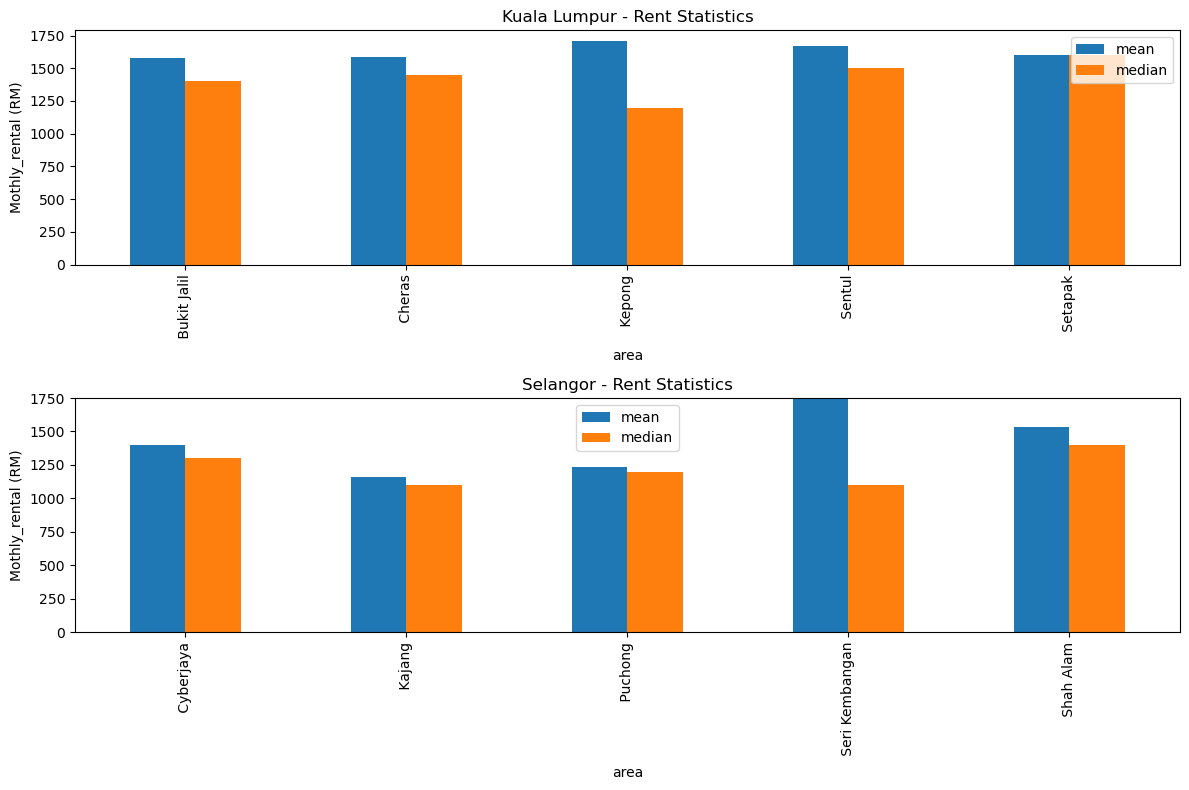

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

kl_results.plot(kind='bar', ax=axes[0], title='Kuala Lumpur - Rent Statistics')
axes[0].set_ylabel('Mothly_rental (RM)')

sgor_results.plot(kind='bar', ax=axes[1], title='Selangor - Rent Statistics')
axes[1].set_ylabel('Mothly_rental (RM)')

plt.ylim(0, 1750)
plt.tight_layout()
plt.show()

#### Figure 5.3. Bar charts showing the rent comparison of the five areas with the largest number of samples in the two cities.

**Observation**

In order to compare the rents in different areas of the same city and to ensure the accuracy of the statistical results, we selected the five areas with the largest number of samples in each city to compare their mean and median. From figure 5.3, we can observe that in Kuala Lumpur, those areas which were developed earlier than others such as Sentul and Setapak and areas with more prosperous commercial centers like Bukit Jalil have higher rents in averange than other normal areas. Whlie in Selangor, we can see that the rent in Sahah Alam, which is considered as the administrative capital, and CyberJaya, which is more technologically advanced, is higher.

#### Conclusion 

Comparing inside the same city, there are a lot of reasons caused the result of different rents in different areas. Comparing the two cities, the average rents are similar, but the average in Kuala Lumpur is higher, and there are more samples with high rents, and the maximum price is also higher.

## **PART 3: PREDICTIVE MODELS**

Based on previous analyses indicating that property size has a stronger influence on monthly rent than the number of rooms or bathrooms, and size is a continuous variable and the most significant predictor, simple linear regression is an appropriate method to model how monthly rent varies with property size.

**1. Linear regression of size and monthly rent**

(19466, 1)
(19466,)
MSE: 394703.0944936038
R²: 0.2149348994169752


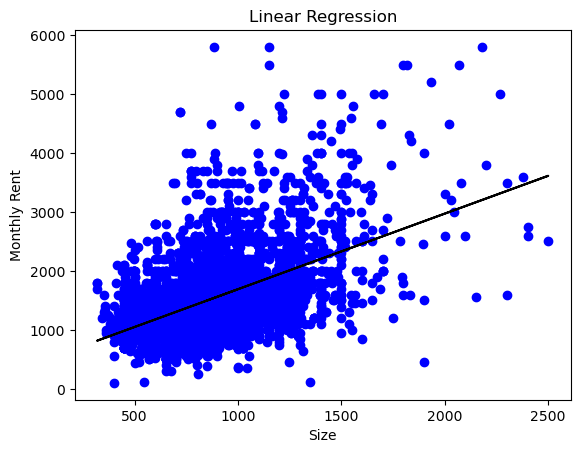

In [69]:
# Load data
data = df_cleaned[['size', 'monthly_rent']].dropna()
X = data[['size']]
y = data['monthly_rent']
print(X.shape)
print(y.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='black')
plt.xlabel("Size")
plt.ylabel("Monthly Rent")
plt.title("Linear Regression")
plt.show()

**Figure 6.1: Linear regression of size and monthly rent**

The linear regression analysis（figure 6.1) shows a positive relationship between property size and monthly rent. As size increases, rent tends to rise as well. However, the R² value is only 0.23, indicating that size alone explains about 23% of the variation in rent. This suggests that while size is an important factor, other factors (such as location or facilities) also play a significant role in determining rental prices.

**Conclusion**  
This analysis investigated the influence of house size, number of rooms, and number of bathrooms on monthly rent. The findings indicate that:
- House size is the strongest predictor of monthly rent, showing a moderate positive correlation (r = 0.47) and a upward trend in the linear regression model, where R² = 0.23.
- Number of rooms, however, shows a weak correlation (r = 0.09) with the monthly rent, which means it has limited impact on rent when considered it independently.
- Number of bathrooms also has a moderate correlation with the monthly rent (r = 0.31).
  
Therefore, monthly rent is most strongly influenced by property size, a property with larger size tends to have higher monthly rent. Number of bathrooms also affect the monthly rent, but rooms count alone is not reliable to predict the rent.

**2. Linear regression of monthly rent and completion year**

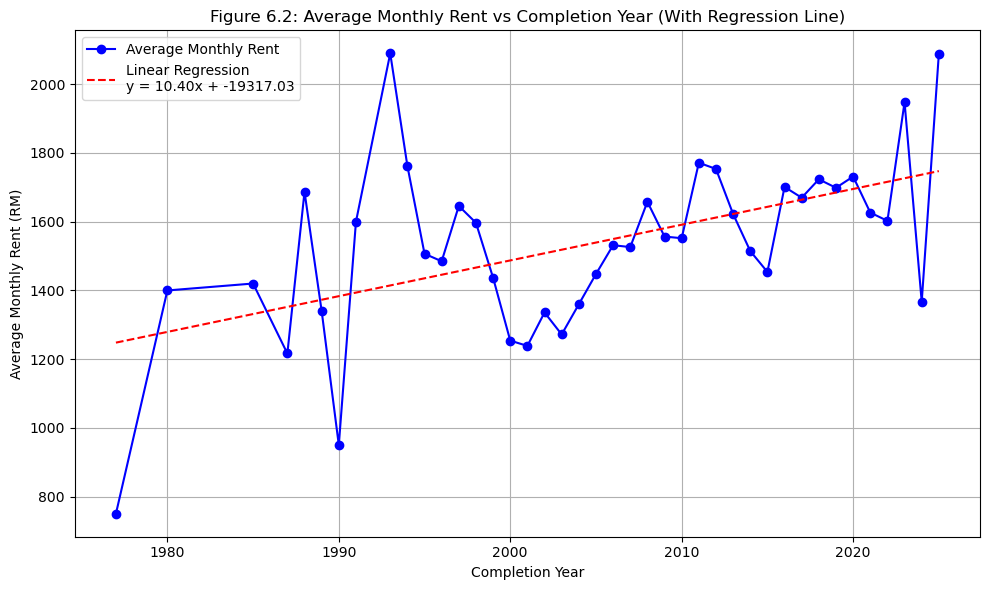

In [70]:
# Drop missing values
df_clean = df.dropna(subset=['completion_year', 'monthly_rent'])

# Remove outliers using IQR
Q1 = df_clean['monthly_rent'].quantile(0.25)
Q3 = df_clean['monthly_rent'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df_clean[(df_clean['monthly_rent'] >= lower_bound) & (df_clean['monthly_rent'] <= upper_bound)]

# Group by completion year and calculate average rent
avg_rent_by_year = df_filtered.groupby('completion_year')['monthly_rent'].mean()
avg_rent_by_year_sorted = avg_rent_by_year.sort_index()

# Get x and y values
x = avg_rent_by_year_sorted.index.values
y = avg_rent_by_year_sorted.values

# Linear regression (y = m*x + c)
m, c = np.polyfit(x, y, 1)
y_pred = m * x + c

# Plot average rent line
plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', linestyle='-', color='blue', label='Average Monthly Rent')

# Plot regression line
plt.plot(x, y_pred, linestyle='--', color='red', label=f'Linear Regression\ny = {m:.2f}x + {c:.2f}')

# Title and labels
plt.title('Figure 6.2: Average Monthly Rent vs Completion Year (With Regression Line)')
plt.xlabel('Completion Year')
plt.ylabel('Average Monthly Rent (RM)')
plt.grid(True)

# Add legend
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

##### Figure 6.2. Average monthly rent of properties based on their completion year.
Based on figure 6.2, the average monthly rent of properties increases as the completion year increases as shown by the linear regression line.

**Conclusion**  
The more recent a property is completed, the higher the average monthly rent.

**3. KNN Model for multiple features** - completion year, property type, bathroom count, size, furnish state with monthly rent

In [72]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

# Choosing features
features = ['completion_year', 'property_type', 'bathroom', 'size', 'furnished']
target = 'monthly_rent'

df_clean = df_cleaned[features + [target]].copy()
df_clean = df_clean.dropna()

# One-hot
df_encoded = pd.get_dummies(df_clean, columns=['property_type', 'furnished'], drop_first=True)

X = df_encoded.drop('monthly_rent', axis=1)
y = df_encoded['monthly_rent']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

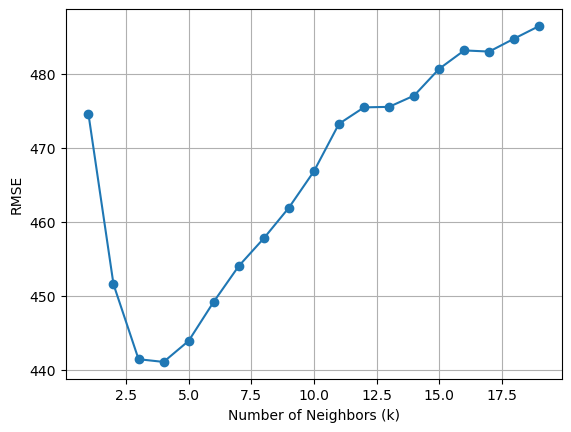

In [73]:
# Find k value
rmse_list = []

for k in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    rmse = root_mean_squared_error(y_test, y_pred)
    rmse_list.append(rmse)

plt.plot(range(1, 20), rmse_list, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.grid()
plt.show()

**Figure 6.3: K vs RMSE**

From the plot above, k=4 gave the lowest error (RMSE) without overfitting.

In [74]:
# Training
model_knn = KNeighborsRegressor(n_neighbors=4)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

rmse = root_mean_squared_error(y_test, y_pred_knn)
r2 = r2_score(y_test, y_pred_knn)

print("KNN Regression:")
print("RMSE:",rmse)
print("R² score:", r2)

KNN Regression:
RMSE: 441.0434408066914
R² score: 0.6170768365100487


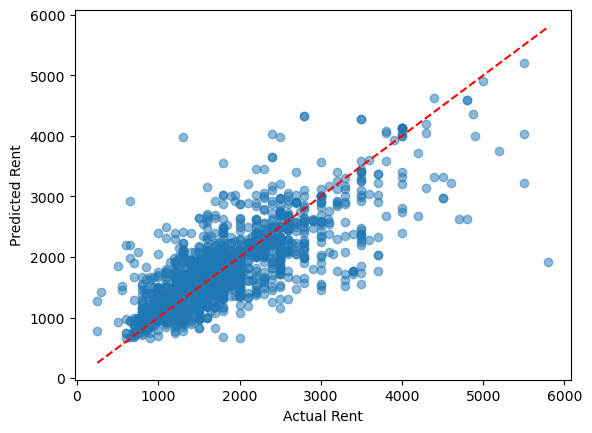

In [75]:
plt.scatter(y_test, y_pred_knn, alpha=0.5)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') 
plt.show()

**Figure 6.4: KNN Regression: Actual vs Predicted Rent**

The model’s performance is shown in the above plot which suggests that with the selected features (`completion_year`, `property_type`, `bathroom`, `size`, `furnished`), monthly rent can be predicted with a relatively high accuracy, with an error of about RM 400 (RMSE = 441.04) and can explain about 62% (R^2 = 0.617) of the properties. This result is not very high because there are still other variables we didn't include will affect monthly rent, such as market demand or extra facilities, which can cause prediction errors in our model.

## **PART 4: PROJECT REPORT**

#### **4.1 Question Selection and Chart Justification**
As the living cost in urban areas, especially in Kuala Lumpur and Selangor keep rising, it has sparked concerns among many residents in terms of housing affordability. Some of those who are affected are young professionals, low to middle family and students living on their own. The research question **`What are Factors Influencing Monthly Rent in Kuala Lumpur and Selangor`** was determined in response to these concerns. This report aims to find out the determinants that contribute to monthly rent prices in Kuala Lumpur and Selangor.

To gain a clearer perspective on the topic, the main research question was broken down to several sub-question. These sub-questions aim to guide the analysis and ensure that different aspects of the monthly rent prices are checked thoroughly. The subquestions are `How do property types influence rental prices?`, `How property size, number of rooms, bathroom, and parking affect the monthly rent prices?`, `How furnishing status impact monthly rent?`,`How completion year impact monthly rent?` `Do special facilities influence the rent of the house?` and `Do rental prices vary across different cities & areas in the data set`


The **first sub-question** which is **`How do property types influence rental prices?`** focuses on examining how different property types affect monthly rent prices. This factor is important as property type directly affects the value of a rental unit. Different property type have different physical structure and layout of a unit, different level of privacy, amenities and maintenance cost. Hence,by examining how property types influence monthly rent prices, this sub-question helps to identify whether certain property types have higher or lower monthly rent and why. This findngs will be useful for both tenants making housing decision and investors or developers assesing the potential profitability of different property type.

To effectively analyze the relationship between property type and monthly rent, a combination of bar charts and box plots were used. These visualizations helped to explore the patterns in this dataset. The bar charts such as *number of property per type* and *distribution of property according to city* provide understanding into the ditribution and availability of different property type in Kuala Lumpur and Selangor, helping to identify which types are more common in a certain area. Other than that, bar charts such as *average monthly rent based on property type* and *average monthly rent based on property type and city* are important in showingbhow rent prices differ across different property type and helps to compare rental trends across different cities.
On the other hand, usage of box plots to visualize *monthly rent by property type* provide valuable insight into variablity and range of rental prices. They show not only medians but also outliers, which are important for understanding rental market consistency and anomalies within each category.


The **second sub-question** which is **`How do property size, number of rooms and bathrooms affect monthly rent?`** was chosen because size, number of rooms and bathrooms are the most basic features that rental properties have, and they are usually the first things people consider when looking for a house. By analysing this question, we can better understand which of these features has a stronger impact on rental prices. This can help tenants make more cost-effective decisions and help landlords set fair and reasonable rental prices based on key property characteristics.

To effective analyze these relationship, few types of charts were chosen. 
Box plots: These box plots visualized the distribution and outliers in both `size` and `monthly rent`, help me to define appropriate range and remove unreliable outliers for data cleaning, which improve the accuracy of my statistical analysis.

Bar charts: Bar charts are used to show the frequency of room and bathroom counts, as well as the median rent for each category. This made it easier to observe how rent varies with different counts of rooms and bathrooms.

Scatter plot: This graph shows the linear relationship between property size and monthly rent, with a trend line clearly showing a positive correlation between the variables.

Heat map: This plot shows the correlation matrix between `size`, `rooms`, `bathrooms`, and `monthly rent`, helping identify which features have stronger relationships with rent by the r values.

Model

Linear regression model: I choose simple linear regression to analyse the relationship between property size and monthly rent because my previous analysis shows that the size has a stronger influence on rent compared to the number of rooms or bathrooms. Since size is a continuous variable and the most important factor, linear regression will be a suitable method to show how monthly rent changes with property size.


The **third sub-question** have two parts under it.First part discusses **`How furnishing status impact monthly rent?`** was chosen because it affects the convenience and readiness of a unit for occupacy. Furnishing status also often influences a tenants' decision-making, such as student, short-term renters or young professionals who may not have the need to furnish a unit themself. Other than that, from a landlord perspective, the level of furnishing justifies the rental charges due to the investment and maintenace involved. By exploring how rent price differs across different furnishing status, it helps to determine the pricing strategies for Kuala Lumpur and Selangor.

Different type of charts were used to identify the trends. For figures on Average Monthly Rent by Furnishing Status, Number of Properties by City and Furnish Status, Average Monthly Rent by Furnish Status in Each City, bar graph is the most suitable way to plot the data as the independent variable (furnish status) is a categorical data and it helps to compare between distinct categories (eg. not furnished, partially furnished and fully furnished). 

The second part discusses **`How completion year of influence monthly rent?`** was chosen as it often reflects the building’s age, condition, and features. Newer properties tend to command higher rental prices because they usually offer modern layouts, updated amenities such as gyms and security systems, and smart home technologies that appeal to today’s renters. These buildings are also more likely to comply with current safety and energy efficiency standards, making them more desirable and comfortable to live in. In contrast, older properties may suffer from outdated designs, maintenance issues, and lower overall appeal, which can lead to lower rental values. As a result, tenants are generally willing to pay more for the added value, convenience, and peace of mind that come with newer developments.

For figure on Average Monthly Rent vs Completion Year, line graph is used to plot the figure as completion year is a continuous and time-based variable. A line graph effectively shows trends over time, making it easy to observe how rental prices increase, decrease, or remain stable across different years. This helps identify patterns, such as whether newer or older buildings tend to command higher rents, and allows for quick visual insights into how rental values have evolved with construction age.

Additionally, a linear regression model is applied to a separate figure on Average Monthly Rent vs Completion Year to  examine the relationship between completion year and average monthly rent. This model is useful because it helps quantify the trend by fitting a straight line through the data points, making it easier to understand whether there's a consistent increase or decrease over time. It also allows us to make predictions and assess how strongly completion year influences rental prices.


The **fourth sub-question** which is **`Do special facilities influence the rent of the house?`** was chosen because special facilities like swimming pool and gym or security services are often marketed as premium features in rental properties. Understand their impact on rent helps landlords,tenants and real estate analysts make informed decisions.
There are a few types of charts used for this sub-question.

**Figure 4.1 Bar plot**

This bar plot compare mean rent for properties with vs without special facilities.
Advantages:
First is that it can highlights which facilities contribute most to higher rents.
Second is that we can easily find that the difference between house with and without special facilities.

**Figure 4.2 Box plot**

Box plot can clearly shown that the difference between the house with and without special facilities from all-round.
Key elements in Box plot:
Median(central line):The meidan rent for properties with special facilities is higher than those without,confirming that amenities command a price premium.

Interquartile Range(IQR):
Wider IQR for the house has special facilities,indicates greater variability in rent price
Narrower IQR for the house dont have special facilities , reflects more consistent,lower rents.

Whiskers and Outliers(Dots):
Outliers above RM3000: More frequent and extreme for properties with amenities, highlighting high-end luxury rentals.

Positively skewed distribution: The “Has special facilities “ box is shifted upward, showing a concentration of mid-range rents with a long tail of expensive outliers

Justification for choosing a box plot
Box plot excel at comparing distributions across categories and recveals differences in central median,spread and skewness for understanding rent disparities.

Handing outliers clearly flag extreme values which could discord mean-based analysis. And also the box plot can provide visualizes the quartiles and range to answering questions”What’s the typical range for each group” and “How do outliers affect the market”

**Figure 4.3 Bar plot**

The purpose of this graph is to compare the influence for each facilities, it clearly show which facility influence the rent most, because it compare the difference between the rent of house has this kind of facility and the average price of all the houses. And rank the facilities by their rent premium.
Advantages;
Easy to comparison across multiple categories
Highlights which facilities contribute most to higher rents(eg. Barbeque area adds ~RM1000)



The **last sub-question** which is **`Do special facilities influence the rent of the house?`** was chosen because cities and areas are the most critical factors shaping rental prices. Cities set the baseline rent levels based on their economic roles—Kuala Lumpur, as the capital and business hub, inherently commands higher rents compared to Selangor, which functions more as a residential suburb. Within cities, local areas further define rent variations. Understanding the difference of city and area is essential before diving into smaller factors like room size or amenities, as they form the foundation of rent differences.

For this subquestion, few different charts and plots such as scatter plot, box plot and bar chart was chosen. The scatter plot visualizes raw rent distribution, making it easy to spot where most prices cluster and how extremes differ between cities. The box plot simplifies statistical comparisons, showing median values, price ranges, and outliers at a glance—ideal for contrasting overall trends in Kuala Lumpur and Selangor. The bar chart focuses on the top five sampled areas in each city, ensuring reliable comparisons. By plotting both mean and median, it reveals whether rents in specific areas are skewed by outliers or reflect consistent pricing.

I also used the data filtering with 0.1%-99.9%  quantiles in cleaning extreme values in step 2. T This method automatically trims the top and bottom 0.1% of rents—filtering typos or non-residential listings—while preserving 99.8% of the data. Unlike fixed thresholds, this approach adapts to the dataset’s natural distribution, ensuring valid high-value cases such as luxury apartments remain intact. This step is important to prevent distorted averages and misleading patterns in the analysis.


#### **4.2 Analysis Findings**
After analysing the **first sub-question** which examines how property type influence monthly rent price, the data reveals that Condominiums are the most common type in the dataset followed by Service Residence and Apartments. The less common types are Service Residence and Soho unit. Even though there are similar number of properties in both Kuala Lumpur and Selangor, Kuala Lumpur consistently shows higher average monthly rent prices across almost all property types. Townhouse Condo in Kuala Lumpur have the highest average monthly rent of approximately RM4700, followed by Condominums, with average monthly rent approximately RM3100, and Service Residence with average monthly rent of approximately RM2900. On the other hand, Residential units have the lowest average monthly rent of approximately RM100. In Selangor, Condominiums have the highest average monthly rent of approximately RM2100, followed by Service Residence and Duplexes. Soho units in Selangor have the lowest average monthly rent.
Based on the box plots, it is evident that most property type average monthly rent fall within RM1000-RM2000 per month. Condominiums and Service Residence have the largest widest rent distribution and highest medians. Flats have the lowest median rent of approximately RM800 and relatively narrow rent ranges. Duplexes and Studios show more consistent pricing with fewer outliers. Comparing rent across property type by city shows that Kuala Lumpur have higher rents across nearly all property type, with notable variation and more frequent outliers, especially in Condominium, Service Residence and Townhouse Condos.

Based on the **second sub-question**, which explores how property size, number of rooms, and number of bathrooms influence monthly rent in Kuala Lumpur and Selangor, it is revealed that there are presence of extreme outliers in both rental prices and property size. Hence, data cleaning was performed by removing missing values and filtering the data. Once the dataset was cleaned, it was observed that most property sizes range from between 500-1250 sqft, with a median size of 889 sqft. Condominium and Townhouse Condos generally have larger size around 1000 sqft, while Studios and Flats are significantly smaller. The majority of properties, nearly 60% have 3 rooms but rent does not increase linearly with the number of rooms. However, a clearer trend is observed with bathrooms, where more number of bathrooms tend to correlate with higher rent. Based on the heatmap analysis, it is observed that size has a moderately positive correlation with monthly rent. Number of bathroom also has a moderate correlation where the r value is equals to 0.31.

Based on the **third sub-question** part 1, furnish status is broken down into 3 parts, namely not furnished, partially furnished and fully furnished. Furnish status significantly influences the average monthly rent of a property, typically with fully furnished units commanding higher rents compared to partially or unfurnished ones. This is largely due to the convenience and move-in readiness that furnished properties offer, especially appealing to expats, students, and professionals who prefer to avoid the cost and effort of furnishing a home. Additionally, the target tenant market varies—fully furnished units often attract short-term renters and expatriates, while unfurnished units are more suitable for long-term tenants or families with existing furniture. Lastly, well-furnished properties create a perception of premium living, which justifies higher rental prices. 

After analysing the second part which investigates the relationship between completion year on properties and average monthly rent, the data indicated that properties completed before year 2000 have higher chances of having fluctuating monthly rents, while properties completed after year 2000 showed signs of having increasing average monthly rents as the completion year becomes more recent. This sign could propably due to the fact that newer properties tend to feature modern designs, amenities, and smart technologies that enhance comfort and appeal, often allowing landlords to charge higher rents. In contrast, older properties may suffer from maintenance issues or outdated facilities, which can lower their rental value unless they are well-maintained or historically significant.

Based on the **fourth sub-question**, which investigates how special facilities affect monthly rent, it is revealed that there is a clear relationship between facilities and rent. This is because properties with special facilities have a higher average monthly rent, around RM 1700 compared to properties without special facilities, that have average monthly rent of RM1200. The median rent is also noticeably higher for properties with special facilites. There is a greater variablity and broader pricing spectrum for properties with special facilities as the rent prices for such properties show a wider interquartile range. A large number of high-end outliers were also found among properties with special facilities. 

Based on the **last sub-question**, which investigates the impact of city and area on monthly rent, it is evident that Kuala Lumpur has higher monthly rent with properties listed above RM2,500 compared to Selangor. In Kuala Lumpur, the highest rent is around RM1800. Meanwhile, in Selangor, the highest rest is around RM1300. Figure 35 shows that Kuala Lumpur has a more even distribution of rent values in the higher price range, where as Selangor has more concentrated rent in lower ranges. Based on Figure 36, which compares five different areas with most listings in each city, it is found that in Kuala Lumpur, older or commercially developed areas like Sentul, Setapak, and Bukit Jalil have higher average monthly rent. In Selangor, The administrative capital, which is Shah Alam and tech hub which is Cyberjaya shows relatively higher rents.

Based on the **predictive models**, Figure 6.1, the linear regression showed a positive correlation between property size and rent. However, the R² value of 0.23 indicate that size alone explains only 23% of rent variation. Based on Figure 6.2, it is observed that the monthly rent increases as the property type is more recent. This can be because newer buildings typically adhere to updated safety and regulatory standards, making them more attractive to tenants and contributing to higher rental prices. 


#### **4.3 Conclusion**
This report aimed to investigate the key factors influencing monthly rent prices in Kuala Lumpur and Selangor. Based on the analysis made, it is revealed that property type, property size, number of bathrooms, furnishing status, availability of special features and location are the most significant factors that influence monthly rent prices in Kuala Lumpur and Selangor.

Property type such as Condominium and Service Residence consistently have higher average monthly rent, especially in Kuala Lumpur where Townhouse Condo has the highest average monthly rent. In terms of physical attributes, properties that are larger and with more bathrooms are generally more expensive. Even though property size correlates positively with rent but it only explain 23% of rent variation, which indicates why the additional factors are important. The furnishing status of a unit also plays a major role as fully furnished units command higher rent as it is more convenient and is more appealing to short term renters. Completion year also plays a vital role in influencing the average monthly rent of a property as average monthly rent increases as the completion year becomes more recent.

Other than that, properties with special facilities such as gyms, pools and enhanced security have significantly higher rent and show a wider range of pricing, including more high end outliers. Lastly, location plays a major role in influecing monthly rent, This is because it is evident that Kuala Lumpur has higher average monthly rent compared to Selangor, especially in commercially developed or centrally located areas such as Bukit Jalil, Setapak and Sentul. Meanwhile in Selangor, due to their administrative and technological significance, Shah Alam and Cybetjaya show elevated rents.

As a conclusion, monthly rent prices are determined by a combinational of structural feature and locational advantages. While there is no a single factor alone that influences monthly rent, it can be concluded properties that are larger, fully furnished, well-located and equipped with special facilites consistently have higher monthly rent price. 